# Simulation Method Validation and PSS Window Sticker

This notebook is analysis-only. Run `examples/IBM_QAOA/run_job.sh` or `examples/IBM_QAOA/run_job_small.sh` first to generate the IBM QAOA campaign artifacts, then load and analyze them here.


In [1]:
# Analysis imports
import functools
import json
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patheffects as _pe
import numpy as np
from matplotlib.lines import Line2D
import pandas as pd
import warnings as _warnings_module
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))

from src.utils import (
    _best_bitstring_ar,
    _detect_method_family,
    _draw_pareto_envelope_segments,
    add_cluster_inset,
    annotate_frontier_depths,
    build_qps_method_color_map,
    family_label_color,
    family_legend_handles,
    _build_hw_frontier,
    _label_depth,
    _label_hw_frontier,
    _pareto_envelope_and_owner,
    _pareto_envelope_bounds,
    _relativize_paths,
    _rescale_resource,
    _scrubbed_formatwarning,
    _sim_entries,
    _sim_winners,
    apply_shared_approx_axis,
    concat_summary,
    cross_strategy_envelope,
    curve_from_training_summary,
    curve_from_window_summary,
    curve_label,
    is_empty_nested_list as _is_empty_nested_list,
    load_cost_model_panels,
    load_multi_strategy_summaries,
    plot_cost_model_comparison_panels,
    plot_multi_method_window_sticker_component_panels,
    plot_parameter_prescriptions_by_resource,
    prepare_monotone_curve,
    save_current_plot,
    shared_approx_ylim as compute_shared_approx_ylim,
    shared_approx_yticks as compute_shared_approx_yticks,
    window_sticker_curve_colors,
)
from src.Processing import (
    QAOAHardware as _QAOAHardware,
    QAOATraining as _QAOATraining,
    set_data_path as _set_data_path,
    load_problem_instance as _load_problem_instance,
    resolve_hardware_training_costs as _resolve_hardware_training_costs,
)
from src.approx_ratio_calc import (
    load_maxcut_instance_context as _load_maxcut_instance_context,
    maxcut_energy_from_bitstring as _maxcut_energy_from_bitstring,
)
from src.simulation_validation import (
    build_resource_frontier_from_exact_points,
    build_strategy_budget_summary,
    estimate_hardware_time_per_shot,
    run_stochastic_benchmark_pss,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams.update({
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'axes.titlesize': 16,
    'figure.titlesize': 16,
})

%load_ext autoreload
%autoreload 2

In [2]:
# Analysis configuration
GRAPH_TYPE = 'heavy_hex'
NUM_NODES = 144
REPO_ROOT = Path('../../..').resolve()
WORKSPACE_ROOT = REPO_ROOT.parent

# warnings.warn's default formatter prints the absolute source-file path of
# the call site (e.g. src/interpolate.py's duplicate-resource warning) --
# unlike print() output, that bypasses _relativize_paths below entirely, so
# committed cell output can leak a contributor's local filesystem layout.
# Strip it down to a path relative to WORKSPACE_ROOT (or the container
# /workspace prefix), matching _relativize_paths' own convention.
_warnings_module.formatwarning = functools.partial(_scrubbed_formatwarning, workspace_root=WORKSPACE_ROOT)

QAOA_PARAMETER_SETTING_ROOT = Path(
    os.environ.get('QAOA_PARAMETER_SETTING_ROOT', WORKSPACE_ROOT / 'QAOA-Parameter-Setting')
).expanduser().resolve()
HARDWARE_RESULTS_ROOT = QAOA_PARAMETER_SETTING_ROOT / 'data' / 'hardware'

RESULT_TAG = 'heavy_hex_144_FA_no_opt_p7_expanded'
RESULT_JOB_P_MATCH = re.search(r'_p(\d+)', RESULT_TAG)
RESULT_JOB_P = int(RESULT_JOB_P_MATCH.group(1)) if RESULT_JOB_P_MATCH else None
INCLUDE_PT_TRANSFER_COST = True
PT_TRANSFER_COST_SECONDS = None  # None uses measured transfer lookup time from PT raw rows.
SHOW_WINDOW_STICKER_CI = False
SKIP_MISSING_MULTI_STRATEGY_SUMMARIES = True

TIME_PER_SHOT = estimate_hardware_time_per_shot(
    HARDWARE_RESULTS_ROOT,
    graph_type=GRAPH_TYPE,
    num_nodes=NUM_NODES,
    job_p=RESULT_JOB_P,
    statistic='median',
    normalize_by_pubs=True,
)
COMPARISON_RESULT_TAGS = [
    'heavy_hex_144_FA_PP_opt_p5_expanded',
    'heavy_hex_144_FA_PP_opt_p6_expanded',
    'heavy_hex_144_FA_PP_opt_p7_expanded',
    'heavy_hex_144_LR_opt_p5_expanded',
    'heavy_hex_144_LR_angle_opt_p5_expanded',
    'heavy_hex_144_LR_opt_p7_expanded',
    'heavy_hex_144_I_full_p7_expanded',
    'heavy_hex_144_PT_p7_expanded',
    'heavy_hex_144_PT_p6_expanded',
    'heavy_hex_144_PT_p5_expanded',
    'heavy_hex_144_PT_p3_expanded',
    'heavy_hex_144_PT_p2_expanded',
    'heavy_hex_144_FA_no_opt_p2_expanded',
    'heavy_hex_144_FA_no_opt_p3_expanded',
    'heavy_hex_144_FA_no_opt_p4_expanded',
    'heavy_hex_144_FA_no_opt_p6_expanded',
    'heavy_hex_144_FA_no_opt_p7_expanded',
]

BS_BOOTSTRAP_RANGE = range(10, 51, 10)
TRAIN_TEST_SPLIT_FRACTION = 0.5

OUTPUT_ROOT = Path(f'../results/pss_window_sticker/{RESULT_TAG}').resolve()
WINDOW_STICKER_DIR = OUTPUT_ROOT / 'window_sticker'
PLOT_DIR = Path('plots').resolve()
PLOT_DIR.mkdir(parents=True, exist_ok=True)

FRONTIER_PATH = OUTPUT_ROOT / 'pss_exp_raw_frontier.pkl'
STRATEGY_EXACT_PATH = OUTPUT_ROOT / 'strategy_raw_points.pkl'
LEGACY_FA_EXACT_PATH = OUTPUT_ROOT / 'fa_raw_points.pkl'
TRANSFER_EXACT_PATH = OUTPUT_ROOT / 'transfer_raw_points.pkl'
LEGACY_PT_EXACT_PATH = OUTPUT_ROOT / 'pt_raw_points.pkl'
TRAIN_SPECS_PATH = OUTPUT_ROOT / 'train_instance_specs.csv'
TEST_SPECS_PATH = OUTPUT_ROOT / 'test_instance_specs.csv'
CODEBOOK_PATH = OUTPUT_ROOT / 'ws_codebooks.json'
FRONTIER_PREVIEW_PATH = OUTPUT_ROOT / 'frontier_preview.csv'
FRONTIER_SUMMARY_PATH = OUTPUT_ROOT / 'frontier_group_summary.csv'

In [3]:
# Load campaign artifacts generated by the terminal script
raw_exact_paths = []
for primary_path, legacy_path in [
    (STRATEGY_EXACT_PATH, LEGACY_FA_EXACT_PATH),
    (TRANSFER_EXACT_PATH, LEGACY_PT_EXACT_PATH),
]:
    raw_path = primary_path if primary_path.exists() else legacy_path
    if raw_path.exists() and raw_path not in raw_exact_paths:
        raw_exact_paths.append(raw_path)

missing_paths = [path for path in [CODEBOOK_PATH] if not path.exists()]
if not raw_exact_paths:
    missing_paths.append(f'{STRATEGY_EXACT_PATH} or {TRANSFER_EXACT_PATH}')
if missing_paths:
    missing = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        'Missing campaign artifacts. Run examples/IBM_QAOA/run_job.sh or '
        'examples/IBM_QAOA/run_job_small.sh first:\n' + missing
    )

exact_frames = [pd.read_pickle(path) for path in raw_exact_paths]
exact_df = pd.concat(exact_frames, ignore_index=True)
ws_codebooks = json.loads(CODEBOOK_PATH.read_text(encoding='utf-8'))

for col in ['N', 'M', 'Q']:
    if col not in exact_df.columns:
        exact_df[col] = 0
    exact_df[col] = pd.to_numeric(exact_df[col], errors='coerce').fillna(0.0)

if 'p' in exact_df.columns:
    exact_p_values = sorted(
        pd.to_numeric(exact_df['p'], errors='coerce').dropna().round().astype(int).unique().tolist()
    )
else:
    exact_p_values = [RESULT_JOB_P] if RESULT_JOB_P is not None else []
TIME_PER_SHOT_BY_P = {}
for p_value in exact_p_values:
    try:
        TIME_PER_SHOT_BY_P[int(p_value)] = estimate_hardware_time_per_shot(
            HARDWARE_RESULTS_ROOT,
            graph_type=GRAPH_TYPE,
            num_nodes=NUM_NODES,
            job_p=int(p_value),
            statistic='median',
            normalize_by_pubs=True,
        )
    except (FileNotFoundError, ValueError):
        TIME_PER_SHOT_BY_P[int(p_value)] = TIME_PER_SHOT

if 'p' in exact_df.columns and TIME_PER_SHOT_BY_P:
    p_for_proxy = pd.to_numeric(exact_df['p'], errors='coerce').round().astype('Int64')
    exact_df['_hardware_time_per_shot'] = p_for_proxy.map(TIME_PER_SHOT_BY_P).astype(float)
    exact_df['_hardware_time_per_shot'] = exact_df['_hardware_time_per_shot'].fillna(TIME_PER_SHOT)
else:
    exact_df['_hardware_time_per_shot'] = TIME_PER_SHOT

training_shot_cost_proxy = exact_df['N'] * exact_df['M'] * exact_df['_hardware_time_per_shot']

# --- Interpolation (RecursionTrainer) training cost ---
# I_MPSAer/I_PP/I_MPS/I_SV route through RecursionTrainer, which chains a
# DepthOneScanTrainer, a p=1 ScipyTrainer, and (p-1) more ScipyTrainer
# sub-optimizations at p=2..target, all sharing the same shot-based
# MPSAerSampleEvaluator (build_sampled_training_config propagates the same
# (N, M) grid point to every recursion depth, not just p=1). Rather than a
# hand-derived N*M*t_shot proxy, use total_training_shots directly -- it's
# populated by _augment_stage_result from the evaluator's real .shots and
# already sums the actual shot count across every stage, including all
# recursion sub-depths.
_INTERP_STRATEGY_NAMES = {'I_MPSAer', 'I_PP', 'I_MPS', 'I_SV'}
_interp_mask = pd.Series(False, index=exact_df.index)
if 'strategy' in exact_df.columns:
    _interp_mask = exact_df['strategy'].astype(str).isin(_INTERP_STRATEGY_NAMES)
if _interp_mask.any() and 'total_training_shots' in exact_df.columns:
    _interp_shots = pd.to_numeric(exact_df.loc[_interp_mask, 'total_training_shots'], errors='coerce')
    training_shot_cost_proxy = training_shot_cost_proxy.copy()
    training_shot_cost_proxy.loc[_interp_mask] = (
        _interp_shots * exact_df.loc[_interp_mask, '_hardware_time_per_shot']
    )
    print(
        f'Interp training cost for {_interp_mask.sum()} rows now uses total_training_shots '
        '(includes all recursion sub-depths, not just N*M for p=1).'
    )

# Detect PT/transfer strategies by name. Use alphanumeric-only boundaries (not \b, which
# treats underscore as a word character) so that 'PT' in '_opt' does NOT match — strategy
# names like 'FA_PP_opt' and 'LR_opt' both contain the substring 'pt' but are not PT strategies.
_PT_PATTERN = (
    r'(?<![a-zA-Z0-9])PT(?![a-zA-Z0-9])'
    r'|Param\.? Transfer|Parameter Transfer'
    r'|(?<![a-zA-Z0-9])transfer(?![a-zA-Z0-9])'
)
transfer_strategy_mask = pd.Series(False, index=exact_df.index)
for transfer_col in ['strategy', 'strategy_family', 'method_label', 'strategy_runtime_label']:
    if transfer_col in exact_df.columns:
        transfer_strategy_mask |= exact_df[transfer_col].astype(str).str.contains(
            _PT_PATTERN,
            case=False,
            regex=True,
            na=False,
        )

pt_transfer_cost_proxy = pd.Series(0.0, index=exact_df.index)
if INCLUDE_PT_TRANSFER_COST and transfer_strategy_mask.any():
    if PT_TRANSFER_COST_SECONDS is None:
        if 'runtime_train_wallclock' in exact_df.columns:
            measured_transfer = pd.to_numeric(exact_df['runtime_train_wallclock'], errors='coerce').fillna(0.0)
        elif 'classical_setup_cost' in exact_df.columns:
            measured_transfer = pd.to_numeric(exact_df['classical_setup_cost'], errors='coerce').fillna(0.0)
        else:
            measured_transfer = pd.Series(0.0, index=exact_df.index)
        pt_transfer_cost_proxy.loc[transfer_strategy_mask] = measured_transfer.loc[transfer_strategy_mask]
    else:
        pt_transfer_cost_proxy.loc[transfer_strategy_mask] = float(PT_TRANSFER_COST_SECONDS)

exact_df['classical_setup_cost_proxy'] = pt_transfer_cost_proxy
exact_df['training_cost_proxy'] = training_shot_cost_proxy + pt_transfer_cost_proxy
exact_df['sampling_cost_proxy'] = exact_df['Q'] * exact_df['_hardware_time_per_shot']
exact_df['T_proxy'] = exact_df['training_cost_proxy'] + exact_df['sampling_cost_proxy']
exact_df['T_exact_proxy'] = exact_df['T_proxy']

stored_frontier_df = pd.read_pickle(FRONTIER_PATH) if FRONTIER_PATH.exists() else pd.DataFrame()
budget_grid_points = int(stored_frontier_df['T'].nunique()) if not stored_frontier_df.empty else 1000

frontier_df = build_resource_frontier_from_exact_points(
    exact_df,
    codebooks=ws_codebooks,
    num_bins=budget_grid_points,
    budget_col='T_proxy',
    scale='log',
)

train_specs_df = pd.read_csv(TRAIN_SPECS_PATH) if TRAIN_SPECS_PATH.exists() else pd.DataFrame()
test_specs_df = pd.read_csv(TEST_SPECS_PATH) if TEST_SPECS_PATH.exists() else pd.DataFrame()
frontier_preview_df = frontier_df.head(30).copy()
frontier_summary_df = frontier_df.groupby(['split', 'strategy'], as_index=False).agg(
    n_rows=('instance', 'size'),
    min_T=('T', 'min'),
    max_T=('T', 'max'),
    best_response=('BestApproximationRatio', 'max'),
)

print('Loaded campaign from:', OUTPUT_ROOT.relative_to(REPO_ROOT))
print(f'Hardware-derived TIME_PER_SHOT: {TIME_PER_SHOT:.12g} s from {HARDWARE_RESULTS_ROOT.relative_to(WORKSPACE_ROOT)} (job_p={RESULT_JOB_P})')
print('Hardware-derived TIME_PER_SHOT_BY_P:', TIME_PER_SHOT_BY_P or {'default': TIME_PER_SHOT})
print('Raw exact artifacts:', [path.name for path in raw_exact_paths])
print(f'Transfer strategy mask fires on {transfer_strategy_mask.sum()} / {len(transfer_strategy_mask)} rows '
      f'({sorted(exact_df.loc[transfer_strategy_mask, "strategy"].unique()) if transfer_strategy_mask.any() else []})')
if INCLUDE_PT_TRANSFER_COST and transfer_strategy_mask.any():
    pt_transfer_values = pt_transfer_cost_proxy.loc[transfer_strategy_mask]
    print(
        'PT transfer preprocessing cost in proxy: '
        f'median={pt_transfer_values.median():.6g} s, '
        f'min={pt_transfer_values.min():.6g} s, '
        f'max={pt_transfer_values.max():.6g} s'
    )
print('Exact rows:', len(exact_df))
print('T_proxy range: [{:.6g}, {:.6g}] s'.format(exact_df['T_proxy'].min(), exact_df['T_proxy'].max()))
print('Clean proxy binned frontier rows:', len(frontier_df))
print('Clean proxy budget bins used:', frontier_df['T'].nunique())
print('Strategies:', sorted(frontier_df['strategy'].dropna().unique()))
print('Splits:', sorted(frontier_df['split'].dropna().unique()))

Loaded campaign from: examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p7_expanded
Hardware-derived TIME_PER_SHOT: 0.000298394097222 s from QAOA-Parameter-Setting/data/hardware (job_p=7)
Hardware-derived TIME_PER_SHOT_BY_P: {7: 0.00029839409722222225}
Raw exact artifacts: ['transfer_raw_points.pkl']
Transfer strategy mask fires on 0 / 390 rows ([])
Exact rows: 390
T_proxy range: [0.0298394, 149.197] s
Clean proxy binned frontier rows: 29970
Clean proxy budget bins used: 999
Strategies: ['FA_PP_no_opt']
Splits: ['test', 'train']


## T_proxy resource accounting

The resource axis $T_{\text{proxy}}$ is the estimated hardware time to run the strategy once on a real device:

$$T_{\text{proxy}} = \underbrace{t_{\text{preprocess}}}_{\text{classical setup}} + \underbrace{N \cdot M \cdot t_{\text{shot}}}_{\text{training shots}} + \underbrace{Q \cdot t_{\text{shot}}}_{\text{sampling shots}}$$

$t_{\text{shot}}$ is estimated from real IBM hardware results (`data/hardware/heavy_hex/`) at the corresponding circuit depth $p$.

### Method-specific adjustments

| Method | Adjustment |
|--------|-----------|
| **FA\*, FA†, LR** | No adjustment. $N \times M$ is the total training shots at depth $p$ (a single `ScipyTrainer` stage, no recursion). |
| **PT** | Adds measured classical preprocessing time $t_{\text{preprocess}}$ (parameter lookup). |
| **INTERP** | Uses `total_training_shots` directly instead of $N \times M$. See below. |

### Interpolation (RecursionTrainer) training cost

`I_MPSAer.json` routes through `RecursionTrainer`, which chains a `DepthOneScanTrainer`, a $p=1$ `ScipyTrainer`, and $(p-1)$ more `ScipyTrainer` sub-optimizations at $p = 2 \ldots p_{\text{target}}$. The PSS campaign builder (`build_sampled_training_config`) propagates the *same* $(N, M)$ grid point to every one of those stages, not just $p=1$, and `RecursionTrainer` shares its nested `ScipyTrainer`'s evaluator (`RecursionTrainer.__init__` passes `trainer.evaluator` up to `BaseTrainer.__init__`), so the real shot count across every recursion sub-depth is already captured in `total_training_shots`:

$$T_{\text{proxy, Interp}} = t_{\text{preprocess}} + \text{total\_training\_shots} \times t_{\text{shot}} + Q \times t_{\text{shot}}$$

**Provenance.** This notebook's Interpolation curve is sourced from campaign
`heavy_hex_144_I_full_p7_expanded`, generated by `interp_full_recursion_job.sh`
(pinned to `qaoa_training_pipeline v0.1.0`, QPS `50a17c6`), which carries the
`MPSAerSampleEvaluator` nested-evaluator change above -- so recursion
sub-depth shots are counted in `total_training_shots` for this campaign's
data. `results/` is not committed, so this line is what makes the figures
reproducible without reading the job script.

In [4]:
# Quick artifact preview
_path_cols = ['graph_path', 'minmax_path']
display(_relativize_paths(train_specs_df, _path_cols, WORKSPACE_ROOT).head(10))
display(_relativize_paths(test_specs_df, _path_cols, WORKSPACE_ROOT).head(10))
display(frontier_preview_df)
display(frontier_summary_df)


,graph_type,num_nodes,instance,degree,swap_layers,er_probability,graph_path,minmax_path,split,source
0,heavy_hex,144,100,NaN,NaN,NaN,data/generated_instances/heavy_hex__n=144__deg...,data/generated_instances/heavy_hex__n=144__deg...,train,generated_train
1,heavy_hex,144,101,NaN,NaN,NaN,data/generated_instances/heavy_hex__n=144__deg...,data/generated_instances/heavy_hex__n=144__deg...,train,generated_train
2,heavy_hex,144,102,NaN,NaN,NaN,data/generated_instances/heavy_hex__n=144__deg...,data/generated_instances/heavy_hex__n=144__deg...,train,generated_train
3,heavy_hex,144,103,NaN,NaN,NaN,data/generated_instances/heavy_hex__n=144__deg...,data/generated_instances/heavy_hex__n=144__deg...,train,generated_train
4,heavy_hex,144,104,NaN,NaN,NaN,data/generated_instances/heavy_hex__n=144__deg...,data/generated_instances/heavy_hex__n=144__deg...,train,generated_train
5,heavy_hex,144,105,NaN,NaN,NaN,data/generated_instances/heavy_hex__n=144__deg...,data/generated_instances/heavy_hex__n=144__deg...,train,generated_train
6,heavy_hex,144,106,NaN,NaN,NaN,data/generated_instances/heavy_hex__n=144__deg...,data/generated_instances/heavy_hex__n=144__deg...,train,generated_train
7,heavy_hex,144,107,NaN,NaN,NaN,data/generated_instances/heavy_hex__n=144__deg...,data/generated_instances/heavy_hex__n=144__deg...,train,generated_train
8,heavy_hex,144,108,NaN,NaN,NaN,data/generated_instances/heavy_hex__n=144__deg...,data/generated_instances/heavy_hex__n=144__deg...,train,generated_train
9,heavy_hex,144,109,NaN,NaN,NaN,data/generated_instances/heavy_hex__n=144__deg...,data/generated_instances/heavy_hex__n=144__deg...,train,generated_train


,graph_type,num_nodes,instance,degree,swap_layers,er_probability,graph_path,minmax_path,split,source
0,heavy_hex,144,0,NaN,NaN,NaN,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,test,repo_test
1,heavy_hex,144,1,NaN,NaN,NaN,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,test,repo_test
2,heavy_hex,144,2,NaN,NaN,NaN,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,test,repo_test
3,heavy_hex,144,3,NaN,NaN,NaN,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,test,repo_test
4,heavy_hex,144,4,NaN,NaN,NaN,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,test,repo_test
5,heavy_hex,144,5,NaN,NaN,NaN,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,test,repo_test
6,heavy_hex,144,6,NaN,NaN,NaN,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,test,repo_test
7,heavy_hex,144,7,NaN,NaN,NaN,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,test,repo_test
8,heavy_hex,144,8,NaN,NaN,NaN,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,test,repo_test
9,heavy_hex,144,9,NaN,NaN,NaN,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,workdirs/fa-no-opt-p7/repos/QAOA-Parameter-Set...,test,repo_test


,graph_type,num_nodes,instance,instance_id,split,source,p,strategy,strategy_family,strategy_runtime_label,simulation_method,N,M,classical_setup_cost,training_cost,sampling_cost,T_exact,classical_setup_cost_proxy,training_cost_proxy,sampling_cost_proxy,T_exact_proxy,runtime_train_wallclock,runtime_sample_wallclock,Q,best_bitstring,best_found_value,BestApproximationRatio,Approximation_Ratio,num_objective_evaluations,total_training_shots,_hardware_time_per_shot,T_proxy,budget_bin,budget_left,budget_right,T,resource,selected_exact_T,selected_exact_T_proxy,budget_distance,strategy_code,simulation_code,train
0,heavy_hex,144,000,000,test,repo_test,7,FA_PP_no_opt,FA,FA_PP_no_opt_7,MPSAer,0,0,0.000017,0.000017,0.132412,0.132429,0.0,0.0,0.029839,0.029839,0.000017,0.132412,100,1101010110111010000101000001010100001000010101...,37.616075,0.791611,0.791611,0,0,0.000298,0.029839,1,0.030095,0.030095,0.030095,0.030095,0.132429,0.029839,0.000255,0.0,0.0,0
1,heavy_hex,144,000,000,test,repo_test,7,FA_PP_no_opt,FA,FA_PP_no_opt_7,MPSAer,0,0,0.000017,0.000017,0.132412,0.132429,0.0,0.0,0.029839,0.029839,0.000017,0.132412,100,1101010110111010000101000001010100001000010101...,37.616075,0.791611,0.791611,0,0,0.000298,0.029839,2,0.030353,0.030353,0.030353,0.030353,0.132429,0.029839,0.000513,0.0,0.0,0
2,heavy_hex,144,000,000,test,repo_test,7,FA_PP_no_opt,FA,FA_PP_no_opt_7,MPSAer,0,0,0.000017,0.000017,0.132412,0.132429,0.0,0.0,0.029839,0.029839,0.000017,0.132412,100,1101010110111010000101000001010100001000010101...,37.616075,0.791611,0.791611,0,0,0.000298,0.029839,3,0.030612,0.030612,0.030612,0.030612,0.132429,0.029839,0.000773,0.0,0.0,0
3,heavy_hex,144,000,000,test,repo_test,7,FA_PP_no_opt,FA,FA_PP_no_opt_7,MPSAer,0,0,0.000017,0.000017,0.132412,0.132429,0.0,0.0,0.029839,0.029839,0.000017,0.132412,100,1101010110111010000101000001010100001000010101...,37.616075,0.791611,0.791611,0,0,0.000298,0.029839,4,0.030875,0.030875,0.030875,0.030875,0.132429,0.029839,0.001035,0.0,0.0,0
4,heavy_hex,144,000,000,test,repo_test,7,FA_PP_no_opt,FA,FA_PP_no_opt_7,MPSAer,0,0,0.000017,0.000017,0.132412,0.132429,0.0,0.0,0.029839,0.029839,0.000017,0.132412,100,1101010110111010000101000001010100001000010101...,37.616075,0.791611,0.791611,0,0,0.000298,0.029839,5,0.031139,0.031139,0.031139,0.031139,0.132429,0.029839,0.001300,0.0,0.0,0
5,heavy_hex,144,000,000,test,repo_test,7,FA_PP_no_opt,FA,FA_PP_no_opt_7,MPSAer,0,0,0.000017,0.000017,0.132412,0.132429,0.0,0.0,0.029839,0.029839,0.000017,0.132412,100,1101010110111010000101000001010100001000010101...,37.616075,0.791611,0.791611,0,0,0.000298,0.029839,6,0.031406,0.031406,0.031406,0.031406,0.132429,0.029839,0.001566,0.0,0.0,0
6,heavy_hex,144,000,000,test,repo_test,7,FA_PP_no_opt,FA,FA_PP_no_opt_7,MPSAer,0,0,0.000017,0.000017,0.132412,0.132429,0.0,0.0,0.029839,0.029839,0.000017,0.132412,100,1101010110111010000101000001010100001000010101...,37.616075,0.791611,0.791611,0,0,0.000298,0.029839,7,0.031674,0.031674,0.031674,0.031674,0.132429,0.029839,0.001835,0.0,0.0,0
7,heavy_hex,144,000,000,test,repo_test,7,FA_PP_no_opt,FA,FA_PP_no_opt_7,MPSAer,0,0,0.000017,0.000017,0.132412,0.132429,0.0,0.0,0.029839,0.029839,0.000017,0.132412,100,1101010110111010000101000001010100001000010101...,37.616075,0.791611,0.791611,0,0,0.000298,0.029839,8,0.031946,0.031946,0.031946,0.031946,0.132429,0.029839,0.002106,0.0,0.0,0
8,heavy_hex,144,000,000,test,repo_test,7,FA_PP_no_opt,FA,FA_PP_no_opt_7,MPSAer,0,0,0.000017,0.000017,0.132412,0.132429,0.0,0.0,0.029839,0.029839,0.000017,0.132412,100,1101010110111010000101000001010100001000010101...,37.616075,0.791611,0.791611,0,0,0.000298,0.029839,9,0.032219,0.032219,0.032219,0.032219,0.132429,0.029839,0.002380,0.0,0.0,0
9,heavy_hex,144,000,000,test,repo_test,7,FA_PP_no_opt,FA,FA_PP_no_opt_7,MPSAer,0,0,0.000017,0.000017,0.132412,0.132429,0.0,0.0,0.029839,0.029839,0.000017,0.132412,100,1101010110111010000101000001010100001000010101...,37.616075,0.791611,0.791611,0,0,0.000298,0.029839,10,0.032495,0.032495,0.032495,0.032495,0.1324

,split,strategy,n_rows,min_T,max_T,best_response
0,test,FA_PP_no_opt,9990,0.030095,149.197049,0.907618
1,train,FA_PP_no_opt,19980,0.030095,149.197049,0.929874


In [5]:
# Inspect the available encoded metadata before running stochastic-benchmark
display(pd.DataFrame({
    'strategy_code': list(ws_codebooks.get('strategy', {}).keys()),
    'strategy_name': list(ws_codebooks.get('strategy', {}).values()),
}))
display(pd.DataFrame({
    'simulation_code': list(ws_codebooks.get('simulation', {}).keys()),
    'simulation_name': list(ws_codebooks.get('simulation', {}).values()),
}))


,strategy_code,strategy_name
0,0,FA_PP_no_opt


,simulation_code,simulation_name
0,0,MPSAer


In [6]:
# Run stochastic-benchmark on the clean proxy resource axis
WS_RESOURCE_AXIS = 'T_proxy'
WS_RESOURCE_FORMULA = 'T_proxy = t_preprocessing + N M t_shot + Q t_shot'
WS_FRONTIER_DF = frontier_df.copy()
WS_FRONTIER_NAME = 'frontier_df'
WS_XLABEL = r'Resource $(T_{\mathrm{proxy}} = t_{\mathrm{preprocessing}} + NMt_{\mathrm{shot}} + Qt_{\mathrm{shot}})$ [s]'
WS_TITLE = f'Window sticker on clean proxy resource: {GRAPH_TYPE}, n={NUM_NODES}'
WS_PLOT_SUFFIX = 'clean_proxy_resource'

# src/bootstrap.py resamples through numpy's global generator and never seeds
# it (issue #86); seed here so re-running this cell retains the same draw.
np.random.seed(0)
ws_results = run_stochastic_benchmark_pss(
    WS_FRONTIER_DF,
    output_dir=WINDOW_STICKER_DIR,
    codebooks=ws_codebooks,
    response_col='BestApproximationRatio',
    resource_col='T',
    response_key='Response',
    bootstrap_range=BS_BOOTSTRAP_RANGE,
    train_test_split=TRAIN_TEST_SPLIT_FRACTION,
    clear_checkpoints=True,
)

virtual_best_df = ws_results['virtual_best_df']
projection_summary_df = ws_results['projection_summary_df']
window_sticker_summary_df = ws_results['window_sticker_summary_df']

resource_axis_summary_df = pd.DataFrame([
    {
        'axis': WS_RESOURCE_AXIS,
        'formula': WS_RESOURCE_FORMULA,
        'frontier': WS_FRONTIER_NAME,
        'rows': len(WS_FRONTIER_DF),
        'budget_points': WS_FRONTIER_DF['T'].nunique(),
        'resource_min': WS_FRONTIER_DF['T'].min(),
        'resource_max': WS_FRONTIER_DF['T'].max(),
    },
])

print('Clean-proxy raw exp_raw files written:', len(ws_results['written_files']))
display(virtual_best_df)
display(window_sticker_summary_df)
display(resource_axis_summary_df)


100%|██████████| 8/8 [00:00<00:00, 47.62it/s]

100%|██████████| 6/6 [00:00<00:00, 30.06it/s]

100%|██████████| 9/9 [00:00<00:00, 33.77it/s]

100%|██████████| 7/7 [00:00<00:00, 41.00it/s]

100%|██████████| 7/7 [00:00<00:00, 28.15it/s]

100%|██████████| 8/8 [00:00<00:00, 28.71it/s]

100%|██████████| 8/8 [00:00<00:00, 33.00it/s]

100%|██████████| 5/5 [00:00<00:00, 25.34it/s]

100%|██████████| 4/4 [00:00<00:00, 26.69it/s]

100%|██████████| 7/7 [00:00<00:00, 38.63it/s]

100%|██████████| 6/6 [00:00<00:00, 25.03it/s]

100%|██████████| 7/7 [00:00<00:00, 37.94it/s]

100%|██████████| 8/8 [00:00<00:00, 36.95it/s]

100%|██████████| 8/8 [00:00<00:00, 41.14it/s]

100%|██████████| 26/26 [00:00<00:00, 2277.47it/s]


Clean-proxy raw exp_raw files written: 30


,resource,strategy_code,simulation_code,N,M,Q,p,response,response_std,n_instances,response_lower,response_upper,strategy,simulation_method
0,0.050315,0.0,0.0,0.0,0.0,100.0,7.0,0.807099,0.015988,6,0.794305,0.819892,FA_PP_no_opt,MPSAer
1,0.075041,0.0,0.0,0.0,0.0,100.0,7.0,0.841781,0.004423,2,0.835650,0.847911,FA_PP_no_opt,MPSAer
2,0.105707,0.0,0.0,0.0,0.0,250.0,7.0,0.817173,0.004191,4,0.813066,0.821280,FA_PP_no_opt,MPSAer
3,0.118496,0.0,0.0,0.0,0.0,100.0,7.0,0.865494,NaN,1,0.865494,0.865494,FA_PP_no_opt,MPSAer
4,0.209753,0.0,0.0,0.0,0.0,500.0,7.0,0.835255,0.021030,2,0.806109,0.864402,FA_PP_no_opt,MPSAer
5,0.371290,0.0,0.0,0.0,0.0,420.0,7.0,0.851984,0.017549,5,0.836602,0.867366,FA_PP_no_opt,MPSAer
6,0.466568,0.0,0.0,0.0,0.0,250.0,7.0,0.812034,NaN,1,0.812034,0.812034,FA_PP_no_opt,MPSAer
7,0.493986,0.0,0.0,0.0,0.0,1000.0,7.0,0.840628,0.026156,2,0.804378,0.876878,FA_PP_no_opt,MPSAer
8,0.736747,0.0,0.0,0.0,0.0,1000.0,7.0,0.872420,NaN,1,0.872420,0.872420,FA_PP_no_opt,MPSAer
9,1.098807,0.0,0.0,0.0,0.0,2500.0,7.0,0.846139,0.013292,3,0.831098,0.861181,FA_PP_no_opt,MPSAer


,resource,strategy,simulation_method,N,M,Q,p,response,response_lower,response_upper
0,0.050315,FA_PP_no_opt,MPSAer,0.0,0.0,100.0,7.0,0.807099,0.794305,0.819892
1,0.075041,FA_PP_no_opt,MPSAer,0.0,0.0,100.0,7.0,0.841781,0.835650,0.847911
2,0.105707,FA_PP_no_opt,MPSAer,0.0,0.0,250.0,7.0,0.817173,0.813066,0.821280
3,0.118496,FA_PP_no_opt,MPSAer,0.0,0.0,100.0,7.0,0.865494,0.865494,0.865494
4,0.209753,FA_PP_no_opt,MPSAer,0.0,0.0,500.0,7.0,0.835255,0.806109,0.864402
5,0.371290,FA_PP_no_opt,MPSAer,0.0,0.0,450.0,7.0,0.847718,0.837046,0.858391
6,0.493986,FA_PP_no_opt,MPSAer,0.0,0.0,1000.0,7.0,0.834463,0.810297,0.858630
7,0.736747,FA_PP_no_opt,MPSAer,0.0,0.0,1000.0,7.0,0.872420,0.872420,0.872420
8,1.098807,FA_PP_no_opt,MPSAer,0.0,0.0,2500.0,7.0,0.846139,0.831098,0.861181
9,1.638795,FA_PP_no_opt,MPSAer,0.0,0.0,2500.0,7.0,0.845999,0.813727,0.878271


,axis,formula,frontier,rows,budget_points,resource_min,resource_max
0,T_proxy,T_proxy = t_preprocessing + N M t_shot + Q t_shot,frontier_df,29970,999,0.030095,149.197049


## Window Sticker on Clean Proxy Resource (`T_proxy`)

All Window Sticker results below use `T_proxy = t_preprocessing + N M t_shot + Q t_shot` as the resource coordinate, except for Interpolation strategies (`I_MPSAer`, `I_PP`, `I_MPS`, `I_SV`), which use `total_training_shots * t_shot` in place of `N * M * t_shot` -- see the "T_proxy resource accounting" section above for why. This treats MPSAer as a classical proxy to quantum hardware and ranks prescriptions by the hardware-shot-style budget, while charging any explicit preprocessing cost such as parameter-transfer lookup.

,strategy,simulation_method,p,T,response_mean,response_std,response_min,response_max,N_mean,M_mean,Q_mean,training_cost_mean,sampling_cost_mean,training_cost_proxy_mean,sampling_cost_proxy_mean,T_exact_mean,T_exact_proxy_mean,n_instances,n_candidates
0,FA_PP_no_opt,MPSAer,7,0.030095,0.837647,0.032411,0.773943,0.87912,0.0,0.0,100.0,0.000016,0.140465,0.0,0.029839,0.140481,0.029839,20,20
1,FA_PP_no_opt,MPSAer,7,0.030353,0.837647,0.032411,0.773943,0.87912,0.0,0.0,100.0,0.000016,0.140465,0.0,0.029839,0.140481,0.029839,20,20
2,FA_PP_no_opt,MPSAer,7,0.030612,0.837647,0.032411,0.773943,0.87912,0.0,0.0,100.0,0.000016,0.140465,0.0,0.029839,0.140481,0.029839,20,20
3,FA_PP_no_opt,MPSAer,7,0.030875,0.837647,0.032411,0.773943,0.87912,0.0,0.0,100.0,0.000016,0.140465,0.0,0.029839,0.140481,0.029839,20,20
4,FA_PP_no_opt,MPSAer,7,0.031139,0.837647,0.032411,0.773943,0.87912,0.0,0.0,100.0,0.000016,0.140465,0.0,0.029839,0.140481,0.029839,20,20
5,FA_PP_no_opt,MPSAer,7,0.031406,0.837647,0.032411,0.773943,0.87912,0.0,0.0,100.0,0.000016,0.140465,0.0,0.029839,0.140481,0.029839,20,20
6,FA_PP_no_opt,MPSAer,7,0.031674,0.837647,0.032411,0.773943,0.87912,0.0,0.0,100.0,0.000016,0.140465,0.0,0.029839,0.140481,0.029839,20,20
7,FA_PP_no_opt,MPSAer,7,0.031946,0.837647,0.032411,0.773943,0.87912,0.0,0.0,100.0,0.000016,0.140465,0.0,0.029839,0.140481,0.029839,20,20
8,FA_PP_no_opt,MPSAer,7,0.032219,0.837647,0.032411,0.773943,0.87912,0.0,0.0,100.0,0.000016,0.140465,0.0,0.029839,0.140481,0.029839,20,20
9,FA_PP_no_opt,MPSAer,7,0.032495,0.837647,0.032411,0.773943,0.87912,0.0,0.0,100.0,0.000016,0.140465,0.0,0.029839,0.140481,0.029839,20,20


,resource,strategy_code,simulation_code,N,M,Q,p,response,n_instances,n_virtual_best_rows,strategy,simulation_method
0,0.050315,0.0,0.0,0.0,0.0,100.0,7.0,0.825889,13,13,FA_PP_no_opt,MPSAer
1,0.075041,0.0,0.0,0.0,0.0,100.0,7.0,0.863219,2,2,FA_PP_no_opt,MPSAer
2,0.105707,0.0,0.0,0.0,0.0,250.0,7.0,0.843425,3,3,FA_PP_no_opt,MPSAer
3,0.118496,0.0,0.0,0.0,0.0,100.0,7.0,0.838959,2,2,FA_PP_no_opt,MPSAer
4,0.209753,0.0,0.0,0.0,0.0,500.0,7.0,0.830303,1,1,FA_PP_no_opt,MPSAer
5,0.222080,0.0,0.0,0.0,0.0,100.0,7.0,0.866453,2,2,FA_PP_no_opt,MPSAer
6,0.295468,0.0,0.0,0.0,0.0,250.0,7.0,0.874958,2,2,FA_PP_no_opt,MPSAer
7,0.371290,0.0,0.0,0.0,0.0,500.0,7.0,0.872039,3,3,FA_PP_no_opt,MPSAer
8,0.493986,0.0,0.0,0.0,0.0,1000.0,7.0,0.862084,3,3,FA_PP_no_opt,MPSAer
9,0.586295,0.0,0.0,0.0,0.0,500.0,7.0,0.861515,1,1,FA_PP_no_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,boots,strategy,simulation_method
0,0.050315,0.0,0.0,0.0,0.0,100.0,7.0,24.972947,FA_PP_no_opt,MPSAer
1,0.075041,0.0,0.0,0.0,0.0,100.0,7.0,30.000000,FA_PP_no_opt,MPSAer
2,0.105707,0.0,0.0,0.0,0.0,250.0,7.0,10.000000,FA_PP_no_opt,MPSAer
3,0.118496,0.0,0.0,0.0,0.0,100.0,7.0,25.462419,FA_PP_no_opt,MPSAer
4,0.209753,0.0,0.0,0.0,0.0,500.0,7.0,10.000000,FA_PP_no_opt,MPSAer
5,0.222080,0.0,0.0,0.0,0.0,100.0,7.0,19.164894,FA_PP_no_opt,MPSAer
6,0.295468,0.0,0.0,0.0,0.0,250.0,7.0,16.308128,FA_PP_no_opt,MPSAer
7,0.371290,0.0,0.0,0.0,0.0,500.0,7.0,19.357415,FA_PP_no_opt,MPSAer
8,0.493986,0.0,0.0,0.0,0.0,1000.0,7.0,23.499559,FA_PP_no_opt,MPSAer
9,0.586295,0.0,0.0,0.0,0.0,500.0,7.0,30.000000,FA_PP_no_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,boots,strategy,simulation_method
0,0.050315,0.0,0.0,NaN,NaN,100.000000,7.0,24.972947,FA_PP_no_opt,MPSAer
1,0.075041,0.0,0.0,NaN,NaN,100.000000,7.0,30.000000,FA_PP_no_opt,MPSAer
2,0.105707,0.0,0.0,NaN,NaN,100.000000,7.0,10.000000,FA_PP_no_opt,MPSAer
3,0.118496,0.0,0.0,NaN,NaN,109.605334,7.0,25.462419,FA_PP_no_opt,MPSAer
4,0.209753,0.0,0.0,NaN,NaN,198.383779,7.0,10.000000,FA_PP_no_opt,MPSAer
5,0.222080,0.0,0.0,NaN,NaN,210.510424,7.0,19.164894,FA_PP_no_opt,MPSAer
6,0.295468,0.0,0.0,NaN,NaN,283.211472,7.0,16.308128,FA_PP_no_opt,MPSAer
7,0.371290,0.0,0.0,NaN,NaN,359.071247,7.0,19.357415,FA_PP_no_opt,MPSAer
8,0.493986,0.0,0.0,NaN,NaN,483.078673,7.0,23.499559,FA_PP_no_opt,MPSAer
9,0.586295,0.0,0.0,NaN,NaN,577.191870,7.0,30.000000,FA_PP_no_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,response,response_std,n_instances,response_lower,response_upper,strategy,simulation_method
0,0.050315,0.0,0.0,0.0,0.0,100.000000,7.0,0.825889,0.032058,13,0.808462,0.843316,FA_PP_no_opt,MPSAer
1,0.075041,0.0,0.0,0.0,0.0,100.000000,7.0,0.863219,0.001460,2,0.861195,0.865242,FA_PP_no_opt,MPSAer
2,0.105707,0.0,0.0,0.0,0.0,250.000000,7.0,0.843425,0.027408,3,0.812410,0.874441,FA_PP_no_opt,MPSAer
3,0.118496,0.0,0.0,0.0,0.0,100.000000,7.0,0.838959,0.024968,4,0.814491,0.863428,FA_PP_no_opt,MPSAer
4,0.209753,0.0,0.0,0.0,0.0,500.000000,7.0,0.830303,NaN,1,0.830303,0.830303,FA_PP_no_opt,MPSAer
5,0.222080,0.0,0.0,0.0,0.0,100.000000,7.0,0.866453,0.011571,4,0.855114,0.877792,FA_PP_no_opt,MPSAer
6,0.295468,0.0,0.0,0.0,0.0,250.000000,7.0,0.874958,0.037795,2,0.822577,0.927339,FA_PP_no_opt,MPSAer
7,0.371290,0.0,0.0,0.0,0.0,500.000000,7.0,0.875208,0.011320,4,0.864114,0.886302,FA_PP_no_opt,MPSAer
8,0.493986,0.0,0.0,0.0,0.0,1000.000000,7.0,0.855367,0.029544,4,0.826415,0.884320,FA_PP_no_opt,MPSAer
9,0.586295,0.0,0.0,0.0,0.0,500.000000,7.0,0.861515,NaN,1,0.861515,0.861515,FA_PP_no_opt,MPSAer


...

,resource,strategy_code,simulation_code,N,M,Q,p,response,response_std,n_instances,response_lower,response_upper,strategy,simulation_method
0,0.050315,0.0,0.0,0.0,0.0,100.0,7.0,0.807099,0.015988,6,0.794305,0.819892,FA_PP_no_opt,MPSAer
1,0.075041,0.0,0.0,0.0,0.0,100.0,7.0,0.841781,0.004423,2,0.835650,0.847911,FA_PP_no_opt,MPSAer
2,0.105707,0.0,0.0,0.0,0.0,250.0,7.0,0.817173,0.004191,4,0.813066,0.821280,FA_PP_no_opt,MPSAer
3,0.118496,0.0,0.0,0.0,0.0,100.0,7.0,0.865494,0.000000,2,0.865494,0.865494,FA_PP_no_opt,MPSAer
4,0.209753,0.0,0.0,0.0,0.0,500.0,7.0,0.835255,0.021030,2,0.806109,0.864402,FA_PP_no_opt,MPSAer
5,0.371290,0.0,0.0,0.0,0.0,450.0,7.0,0.847718,0.015401,8,0.837046,0.858391,FA_PP_no_opt,MPSAer
6,0.493986,0.0,0.0,0.0,0.0,1000.0,7.0,0.834463,0.021356,3,0.810297,0.858630,FA_PP_no_opt,MPSAer
7,0.736747,0.0,0.0,0.0,0.0,1000.0,7.0,0.872420,0.000000,2,0.872420,0.872420,FA_PP_no_opt,MPSAer
8,1.098807,0.0,0.0,0.0,0.0,2500.0,7.0,0.846139,0.013292,3,0.831098,0.861181,FA_PP_no_opt,MPSAer
9,1.638795,0.0,0.0,0.0,0.0,2500.0,7.0,0.845999,0.028519,3,0.813727,0.878271,FA_PP_no_opt,MPSAer


,parameter,expression,num_knots
0,Q,"Q(T): monotonic power law (non-decreasing), Q ...",2


,graph type,num nodes,resource axis,fitted strategy,fitted p,fitted N,fitted M,fitted Q,fitted response
0,heavy_hex,144,T_proxy,FA_PP_no_opt,7.0,0.0,0.0,50000.0,0.895936


,dataset,n_rows,resource_min,resource_max
0,train frontier_df,19980,0.030095,149.197049
1,test frontier_df,9990,0.030095,149.197049
2,train virtual-best lookup,37,0.050315,100.036173
3,fitted prescription test,23,0.050315,100.036173


Actionable prescription equations on T_proxy:
  Q(T): monotonic power law (non-decreasing), Q = 1005 * T^1.039
Saved: plots/cost_vs_best_approximation_ratio_clean_proxy_resource.pdf and .png


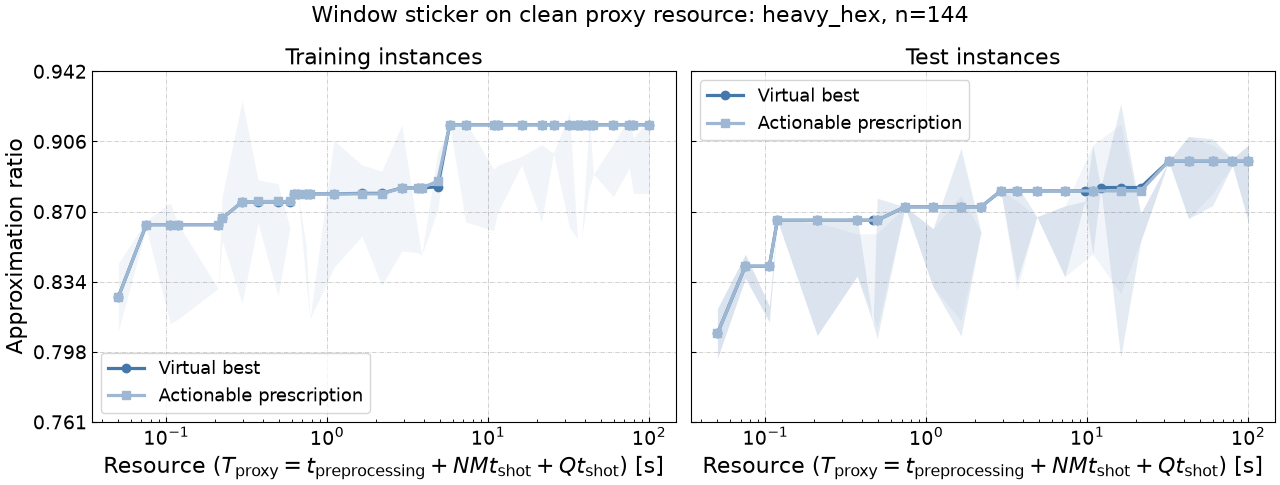

Saved: plots/parameter_prescriptions_clean_proxy_resource.pdf and .png


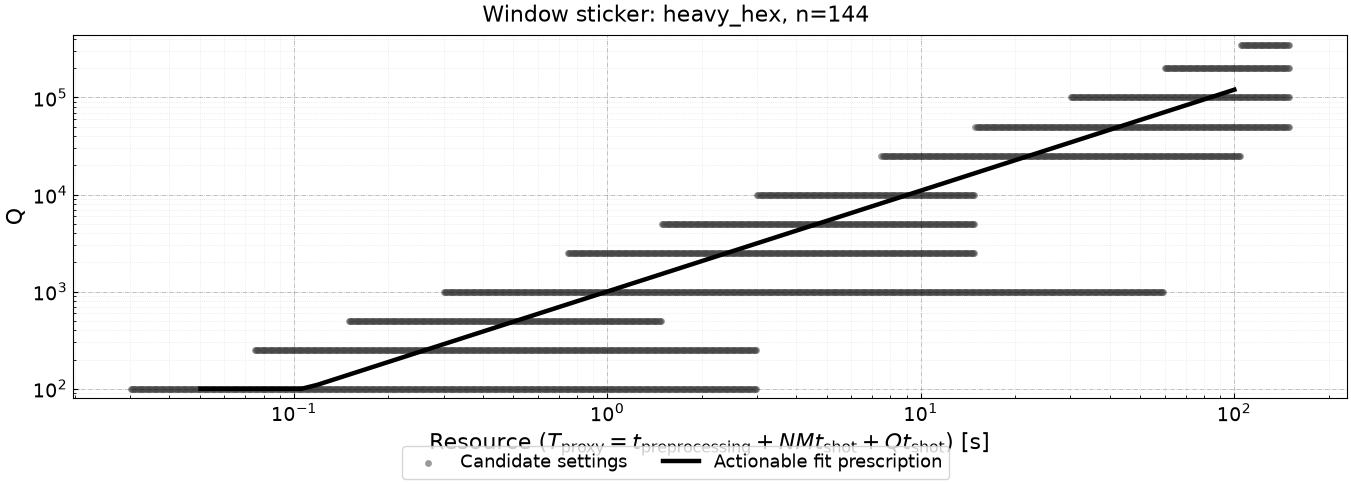

,strategy,T,ApproximationRatio
0,FA_PP_no_opt,0.030095,0.837647
1,FA_PP_no_opt,0.030353,0.837647
2,FA_PP_no_opt,0.030612,0.837647
3,FA_PP_no_opt,0.030875,0.837647
4,FA_PP_no_opt,0.031139,0.837647
...,...,...,...
994,FA_PP_no_opt,144.194781,0.899490
995,FA_PP_no_opt,145.429401,0.899490
996,FA_PP_no_opt,146.674591,0.899490
997,FA_PP_no_opt,147.930444,0.899490


Saved: plots/per_method_cost_performance_clean_proxy_resource.pdf and .png


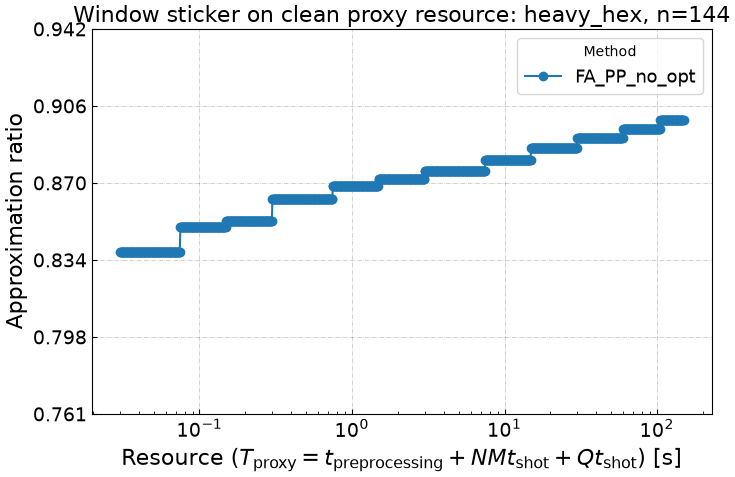

Saved: plots/monotone_envelope_comparison_clean_proxy_resource.pdf and .png


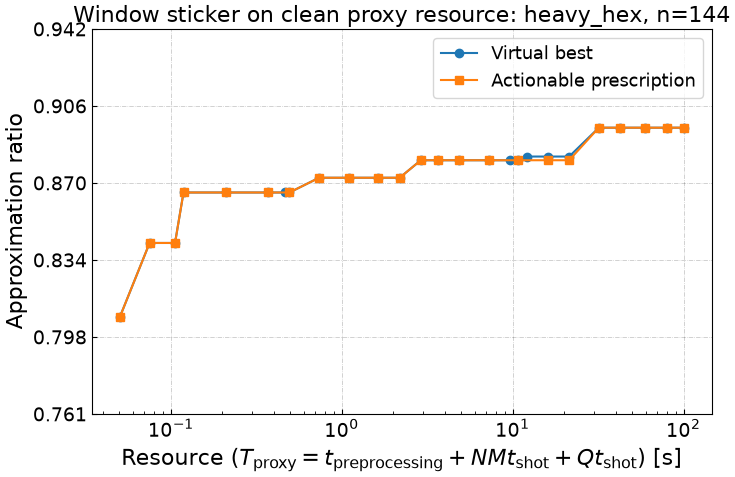

In [7]:
# Active-resource summaries and plots
strategy_budget_df = build_strategy_budget_summary(WS_FRONTIER_DF, split='train')
vb_train_lookup_df = ws_results['vb_train_lookup_df'].copy()
lookup_recipe_train_df = ws_results['recipe_train_df'].copy()
lookup_train_eval_df = ws_results['actionable_train_eval_df'].copy()
fitted_recipe_train_df = ws_results['fitted_recipe_df'].copy()
fitted_train_eval_df = ws_results['fitted_train_eval_df'].copy()
fitted_test_eval_df = ws_results['fitted_test_eval_df'].copy()
fitted_recipe_model_df = ws_results['fitted_recipe_model_df'].copy()
lookup_test_eval_df = window_sticker_summary_df.copy()

best_fitted_df = fitted_test_eval_df.sort_values(['response', 'resource'], ascending=[False, True]).reset_index(drop=True)
recommendation_summary = pd.DataFrame([
    {
        'graph type': GRAPH_TYPE,
        'num nodes': NUM_NODES,
        'resource axis': WS_RESOURCE_AXIS,
        'fitted strategy': best_fitted_df.iloc[0]['strategy'] if not best_fitted_df.empty else None,
        'fitted p': best_fitted_df.iloc[0]['p'] if not best_fitted_df.empty else None,
        'fitted N': best_fitted_df.iloc[0]['N'] if not best_fitted_df.empty else None,
        'fitted M': best_fitted_df.iloc[0]['M'] if not best_fitted_df.empty else None,
        'fitted Q': best_fitted_df.iloc[0]['Q'] if not best_fitted_df.empty else None,
        'fitted response': best_fitted_df.iloc[0]['response'] if not best_fitted_df.empty else None,
    }
])

display(strategy_budget_df.head(20))
display(vb_train_lookup_df.head(20))
display(lookup_recipe_train_df.head(20))
display(fitted_recipe_train_df.head(20))
display(lookup_train_eval_df.head(20))
display(fitted_train_eval_df.head(20))
display(fitted_test_eval_df.head(20))
display(fitted_recipe_model_df)
display(recommendation_summary)

resource_support_debug_df = pd.DataFrame([
    {
        'dataset': f'train {WS_FRONTIER_NAME}',
        'n_rows': len(WS_FRONTIER_DF[WS_FRONTIER_DF['split'].astype(str).eq('train')]),
        'resource_min': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('train'), 'T'].min(),
        'resource_max': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('train'), 'T'].max(),
    },
    {
        'dataset': f'test {WS_FRONTIER_NAME}',
        'n_rows': len(WS_FRONTIER_DF[WS_FRONTIER_DF['split'].astype(str).eq('test')]),
        'resource_min': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('test'), 'T'].min(),
        'resource_max': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('test'), 'T'].max(),
    },
    {
        'dataset': 'train virtual-best lookup',
        'n_rows': len(vb_train_lookup_df),
        'resource_min': vb_train_lookup_df['resource'].min() if not vb_train_lookup_df.empty else None,
        'resource_max': vb_train_lookup_df['resource'].max() if not vb_train_lookup_df.empty else None,
    },
    {
        'dataset': 'fitted prescription test',
        'n_rows': len(fitted_test_eval_df),
        'resource_min': fitted_test_eval_df['resource'].min() if not fitted_test_eval_df.empty else None,
        'resource_max': fitted_test_eval_df['resource'].max() if not fitted_test_eval_df.empty else None,
    },
])
display(resource_support_debug_df)

if not fitted_recipe_model_df.empty:
    print(f'Actionable prescription equations on {WS_RESOURCE_AXIS}:')
    for expression in fitted_recipe_model_df['expression'].dropna().tolist():
        print('  ' + expression)

shared_approx_ylim = compute_shared_approx_ylim(
    virtual_best_df.get('response'),
    fitted_test_eval_df.get('response'),
    lookup_test_eval_df.get('response'),
    vb_train_lookup_df.get('response'),
    lookup_train_eval_df.get('response'),
    fitted_train_eval_df.get('response'),
    strategy_budget_df.get('response_mean'),
    WS_FRONTIER_DF.get('BestApproximationRatio'),
)
shared_approx_yticks = compute_shared_approx_yticks(shared_approx_ylim)

train_virtual_best_monotone_df = prepare_monotone_curve(vb_train_lookup_df)
lookup_train_monotone_df = prepare_monotone_curve(lookup_train_eval_df)
fitted_train_monotone_df = prepare_monotone_curve(fitted_train_eval_df)
test_virtual_best_monotone_df = prepare_monotone_curve(virtual_best_df)
lookup_test_monotone_df = prepare_monotone_curve(lookup_test_eval_df)
fitted_test_monotone_df = prepare_monotone_curve(fitted_test_eval_df)

xlabel = WS_XLABEL
exact_ylabel = 'Approximation ratio'
main_title = WS_TITLE
single_method_label = curve_label(strategy_budget_df, RESULT_TAG)
single_method_colors = window_sticker_curve_colors(single_method_label)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
plot_specs = [
    (axes[0], train_virtual_best_monotone_df, fitted_train_monotone_df, lookup_train_monotone_df, 'Training instances'),
    (axes[1], test_virtual_best_monotone_df, fitted_test_monotone_df, lookup_test_monotone_df, 'Test instances'),
]
for ax, vb_curve, fitted_curve, lookup_curve, title in plot_specs:
    for curve, color_key, label, marker, linewidth, alpha in [
        (vb_curve, 'virtual_best', 'Virtual best', 'o', 2.3, 1.0),
        (fitted_curve, 'actionable_prescription', 'Actionable prescription', 's', 2.3, 1.0),
    ]:
        if curve.empty:
            continue
        color = single_method_colors[color_key]
        lower_col = 'response_lower_monotone' if 'response_lower_monotone' in curve.columns else 'response_lower'
        upper_col = 'response_upper_monotone' if 'response_upper_monotone' in curve.columns else 'response_upper'
        if lower_col in curve.columns and upper_col in curve.columns:
            band = curve.dropna(subset=['resource', lower_col, upper_col])
            if not band.empty:
                ax.fill_between(
                    band['resource'].to_numpy(dtype=float),
                    band[lower_col].to_numpy(dtype=float),
                    band[upper_col].to_numpy(dtype=float),
                    color=color,
                    alpha=0.14,
                    linewidth=0,
                    zorder=1,
                )
        if linewidth > 0:
            ax.plot(
                curve['resource'],
                curve['response_monotone'],
                color=color,
                marker=marker,
                linewidth=linewidth,
                label=label,
                zorder=3,
            )
        else:
            ax.scatter(
                curve['resource'],
                curve['response_monotone'],
                color=color,
                marker=marker,
                s=34,
                alpha=alpha,
                label=label,
                zorder=3,
            )
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    apply_shared_approx_axis(ax, ylim=shared_approx_ylim, yticks=shared_approx_yticks)
    ax.legend()
axes[0].set_ylabel(exact_ylabel)
fig.suptitle(main_title)
fig.tight_layout()
save_current_plot(f'cost_vs_best_approximation_ratio_{WS_PLOT_SUFFIX}', PLOT_DIR)
plt.show()

active_candidate_parameter_df = WS_FRONTIER_DF[
    WS_FRONTIER_DF['split'].astype(str).eq('train')
].drop_duplicates(['instance', 'N', 'M', 'Q', 'T']).copy()

plot_parameter_prescriptions_by_resource(
    candidate_df=active_candidate_parameter_df,
    virtual_best_df=vb_train_lookup_df,
    lookup_df=lookup_train_eval_df,
    actionable_df=fitted_recipe_train_df,
    candidate_resource_col='T',
    curve_resource_col='resource',
    plot_dir=PLOT_DIR,
    filename=f'parameter_prescriptions_{WS_PLOT_SUFFIX}',
    title=f'Window sticker: {GRAPH_TYPE}, n={NUM_NODES}',
    xlabel=xlabel,
    connect_points=True,
    connect_lookup=False,
    show_virtual_best=False,
    show_lookup=False,
    actionable_marker=None,
)

per_method_curve_df = strategy_budget_df.loc[:, ['strategy', 'T', 'response_mean']].rename(columns={'response_mean': 'ApproximationRatio'})
display(per_method_curve_df)
plt.figure(figsize=(8, 5))
for strategy_name, group in per_method_curve_df.groupby('strategy'):
    plt.plot(group['T'], group['ApproximationRatio'], marker='o', label=strategy_name)
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(exact_ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend(title='Method')
save_current_plot(f'per_method_cost_performance_{WS_PLOT_SUFFIX}', PLOT_DIR)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(test_virtual_best_monotone_df['resource'], test_virtual_best_monotone_df['response_monotone'], marker='o', label='Virtual best')
plt.plot(fitted_test_monotone_df['resource'], fitted_test_monotone_df['response_monotone'], marker='s', label='Actionable prescription')
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(exact_ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend()
save_current_plot(f'monotone_envelope_comparison_{WS_PLOT_SUFFIX}', PLOT_DIR)
plt.show()

## Multi-Strategy Window Sticker Comparison

This section compares completed strategy roots listed in `COMPARISON_RESULT_TAGS`. Each result root must first have its single-strategy Window Sticker summary generated (`window_sticker_summary.csv`). Training summaries are loaded when present and rebuilt from `pss_exp_raw_frontier.pkl` when needed.


Loaded strategy roots:
  Fixed Angles$^\star$ (p=5): examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded
  Fixed Angles$^\star$ (p=6): examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p6_expanded
  Fixed Angles$^\star$ (p=7): examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p7_expanded
  Linear Ramp (p=5): examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_LR_opt_p5_expanded
  Linear Ramp$^\star$ (p=5): examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_LR_angle_opt_p5_expanded
  Linear Ramp (p=7): examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_LR_opt_p7_expanded
  Interp.$^\star$ (p=7): examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_I_full_p7_expanded
  Param. Transfer (p=7): examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_PT_p7_expanded
  Param. Transfer (p=6): examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_PT_p6_expanded
  Param. Transfer (p=5): example

,method_label,strategy,simulation_method,p,T,response_mean,N_mean,M_mean,Q_mean,T_exact_proxy_mean,n_instances,n_candidates
0,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000500,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
1,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000503,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
2,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000507,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
3,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000510,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
4,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000514,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
5,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000517,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
6,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000520,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
7,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000524,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
8,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000527,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
9,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000531,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0


Per-method resource ranges:
                                 min         max
method_label                                    
Fixed Angles$^\star$ (p=5)  0.073852   37.488726
Fixed Angles$^\star$ (p=6)  0.072661   24.641105
Fixed Angles$^\star$ (p=7)  0.080133   47.743056
Fixed Angles† (p=2)         0.045741  114.278956
Fixed Angles† (p=3)         0.045741  114.278956
Fixed Angles† (p=4)         0.045741  114.278956
Fixed Angles† (p=6)         0.046132  116.163644
Fixed Angles† (p=7)         0.050315  100.036173
Interp.$^\star$ (p=7)       0.993337  419.049580
Linear Ramp (p=5)           0.070595   34.011838
Linear Ramp (p=7)           0.075171   31.895639
Linear Ramp$^\star$ (p=5)   0.073852   37.488726
Param. Transfer (p=2)       0.053165   77.496237
Param. Transfer (p=3)       0.047412   81.463301
Param. Transfer (p=5)       0.055905   84.244581
Param. Transfer (p=6)       0.053056   82.826755
Param. Transfer (p=7)       0.058620   89.806244

Data-driven xlim: (0.9933, 24.64) s
Save

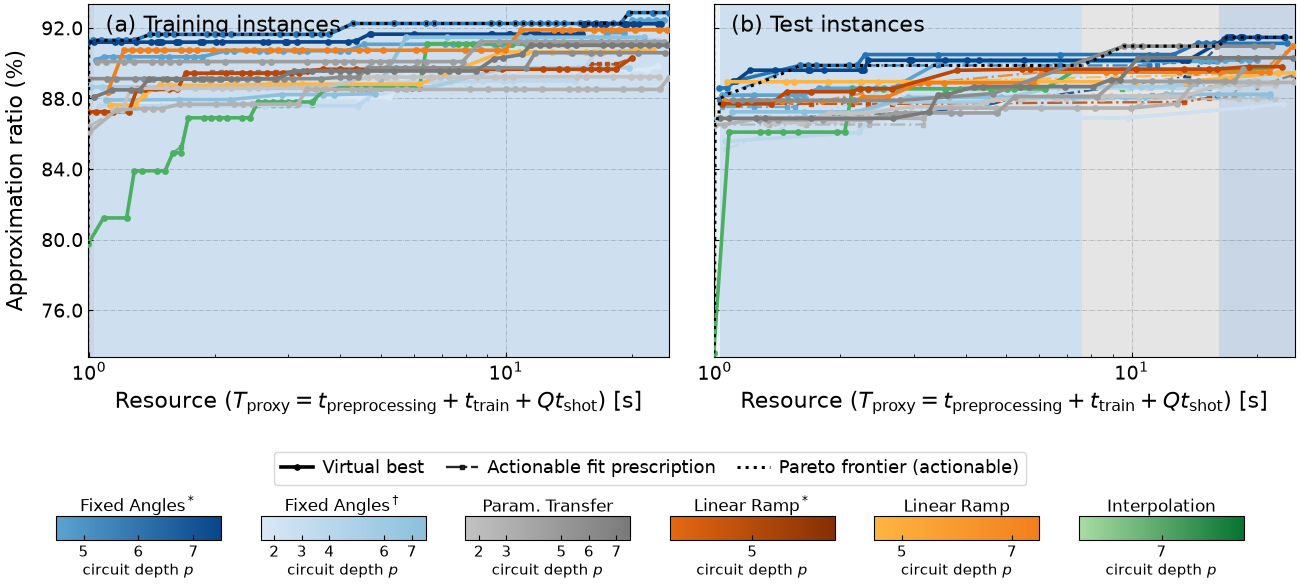

In [8]:
# Multi-strategy actionable PSS comparison
# Add future strategy result tags here after those campaigns finish.
MULTI_STRATEGY_RESULT_TAGS = list(COMPARISON_RESULT_TAGS)

PSS_RESULTS_BASE = OUTPUT_ROOT.parent

required_summary_files = ['window_sticker_summary.csv']
missing_summary_files = []
for tag in MULTI_STRATEGY_RESULT_TAGS:
    root = PSS_RESULTS_BASE / tag
    for filename in required_summary_files:
        if not (root / filename).exists():
            missing_summary_files.append(root / filename)
if missing_summary_files:
    print('Missing Window Sticker summary files for multi-strategy comparison:')
    for path in missing_summary_files:
        print(f'  {path}')
    if SKIP_MISSING_MULTI_STRATEGY_SUMMARIES:
        missing_tags = {path.parent.name for path in missing_summary_files}
        MULTI_STRATEGY_RESULT_TAGS = [
            tag for tag in MULTI_STRATEGY_RESULT_TAGS if tag not in missing_tags
        ]
        print('Skipping unfinished strategy roots:', sorted(missing_tags))
    else:
        raise FileNotFoundError(
            'Generate the missing single-strategy Window Sticker summary first. '
            'For a new strategy, rerun its load + Window Sticker cells once.'
        )

multi_strategy_summaries = load_multi_strategy_summaries(MULTI_STRATEGY_RESULT_TAGS, PSS_RESULTS_BASE)
print('Loaded strategy roots:')
for item in multi_strategy_summaries:
    print(f"  {item['method_label']}: {os.path.relpath(item['root'], REPO_ROOT)}")

multi_strategy_budget_df = concat_summary(multi_strategy_summaries, 'strategy_budget')
multi_actionable_lookup_df = concat_summary(multi_strategy_summaries, 'actionable_lookup')
multi_actionable_fit_df = concat_summary(multi_strategy_summaries, 'actionable_fit')
multi_window_sticker_df = concat_summary(multi_strategy_summaries, 'window_sticker')
multi_virtual_best_df = concat_summary(multi_strategy_summaries, 'virtual_best')
multi_virtual_best_train_df = concat_summary(multi_strategy_summaries, 'virtual_best_train')
multi_fitted_projection_train_df = concat_summary(multi_strategy_summaries, 'fitted_projection_train')
multi_fitted_projection_test_df = concat_summary(multi_strategy_summaries, 'fitted_projection_test')

training_strategy_curve_df = curve_from_training_summary(multi_strategy_budget_df)
training_virtual_best_component_cols = [
    col for col in [
        'method_label', 'T', 'response_monotone',
        'response_lower_monotone', 'response_upper_monotone',
    ]
    if col in training_strategy_curve_df.columns
]
training_virtual_best_components_df = training_strategy_curve_df.loc[
    :, training_virtual_best_component_cols
].rename(
    columns={
        'T': 'resource',
        'response_monotone': 'response',
        'response_lower_monotone': 'response_lower',
        'response_upper_monotone': 'response_upper',
    }
)
training_strategy_envelope_df = cross_strategy_envelope(training_strategy_curve_df, 'T')

actionable_projection_curve_df = curve_from_window_summary(multi_window_sticker_df)
actionable_projection_envelope_df = cross_strategy_envelope(actionable_projection_curve_df, 'resource')

# This table is the direct answer to: which hyperparameters define the strategy curve at each budget?
hyperparameter_lookup_cols = [
    col for col in [
        'method_label', 'strategy', 'simulation_method', 'p', 'T', 'response_mean',
        'N_mean', 'M_mean', 'Q_mean', 'T_exact_proxy_mean', 'n_instances', 'n_candidates',
    ]
    if col in multi_actionable_lookup_df.columns
]
hyperparameter_lookup_df = multi_actionable_lookup_df.loc[:, hyperparameter_lookup_cols].copy() if hyperparameter_lookup_cols else pd.DataFrame()

if not hyperparameter_lookup_df.empty:
    hyperparameter_lookup_df.to_csv(OUTPUT_ROOT / 'multi_strategy_hyperparameter_lookup.csv', index=False)
if not training_strategy_envelope_df.empty:
    training_strategy_envelope_df.to_csv(OUTPUT_ROOT / 'multi_strategy_training_envelope.csv', index=False)
if not actionable_projection_envelope_df.empty:
    actionable_projection_envelope_df.to_csv(OUTPUT_ROOT / 'multi_strategy_actionable_projection_envelope.csv', index=False)

print('Hyperparameter lookup rows:', len(hyperparameter_lookup_df))
display(hyperparameter_lookup_df.head(20))

# Data-driven xlim: intersection of all methods' resource ranges so every curve
# starts and ends at the same plot boundary (tightest common window).
_all_curves = pd.concat(
    [df for df in [
        multi_virtual_best_df, multi_virtual_best_train_df,
        multi_fitted_projection_test_df, multi_fitted_projection_train_df,
    ] if not df.empty and 'resource' in df.columns and 'method_label' in df.columns],
    ignore_index=True,
)
_all_curves['resource'] = pd.to_numeric(_all_curves['resource'], errors='coerce')
_all_curves = _all_curves[_all_curves['resource'] > 0].dropna(subset=['resource'])
_per_method = _all_curves.groupby('method_label')['resource'].agg(['min', 'max'])
_xlim_left = float(_per_method['min'].max())   # latest start across all methods
_xlim_right = float(_per_method['max'].min())  # earliest end across all methods
print(f'Per-method resource ranges:\n{_per_method.to_string()}')
print(f'\nData-driven xlim: ({_xlim_left:.4g}, {_xlim_right:.4g}) s')
MULTI_METHOD_XLIM = (_xlim_left, _xlim_right) if _xlim_left < _xlim_right else None

plot_multi_method_window_sticker_component_panels(
    training_virtual_best_df=multi_virtual_best_train_df,
    training_fitted_prescription_df=multi_fitted_projection_train_df,
    test_virtual_best_df=multi_virtual_best_df,
    test_fitted_prescription_df=multi_fitted_projection_test_df,
    filename='multi_method_window_sticker_component_panels',
    plot_dir=PLOT_DIR,
    approx_ylim=shared_approx_ylim,
    approx_yticks=shared_approx_yticks,
    show_ci=SHOW_WINDOW_STICKER_CI,
    xlim=MULTI_METHOD_XLIM,
)


## Hardware-Calibrated Multi-Strategy Window Sticker

Re-calibrates the x-axis using the **actual IBM hardware shot rate** measured in arXiv:2606.05311v1, rather than per-shot timing extracted from hardware JSON files.

Produced via **post-hoc rescaling** of the existing window-sticker summary files. Each method's resource values are multiplied by $t_{\text{shot,new}}(p)\,/\,t_{\text{shot,hw}}(p)$, where $t_{\text{shot,hw}}$ comes from the local hardware timing JSONs and

$$t_{\text{shot,new}} = 1/2470\,\text{Hz} \approx 405\,\mu\text{s}$$

is the paper-measured wall-clock rate on ibm\_boston, with every sample treated as noiseless. Note: the PT classical preprocessing time is also rescaled (it is small relative to sampling cost and the approximation is negligible).

In [9]:
# ── Hardware calibration parameters (arXiv:2606.05311v1) ─────────────────────
# Paper measures 2.47 kHz wall-clock shot rate on ibm_boston (Sec. III B 1).

PAPER_SHOT_RATE_HZ = 2_470

# Hardware-derived t_shot per depth from local timing JSONs (fallback = p=7 median)
_hw_t_shot_by_p = {}
for _p in range(1, 11):
    try:
        _hw_t_shot_by_p[_p] = estimate_hardware_time_per_shot(
            HARDWARE_RESULTS_ROOT,
            graph_type=GRAPH_TYPE,
            num_nodes=NUM_NODES,
            job_p=_p,
            statistic='median',
            normalize_by_pubs=True,
        )
    except (FileNotFoundError, ValueError):
        _hw_t_shot_by_p[_p] = TIME_PER_SHOT  # no JSON for this p → use p=7 fallback

_t_noiseless = 1.0 / PAPER_SHOT_RATE_HZ
_t_calib_noiseless = {p: _t_noiseless for p in range(1, 11)}

calib_table_df = pd.DataFrame([
    {
        'p': _p,
        't_hw_us':          _hw_t_shot_by_p[_p] * 1e6,
        't_noiseless_us':   _t_calib_noiseless[_p] * 1e6,
        'scale_noiseless':  _t_calib_noiseless[_p] / _hw_t_shot_by_p[_p],
    }
    for _p in range(1, 11)
])
print(f'Paper shot rate: {PAPER_SHOT_RATE_HZ} Hz  →  t_noiseless = {_t_noiseless*1e6:.1f} μs/shot')
display(calib_table_df)


Paper shot rate: 2470 Hz  →  t_noiseless = 404.9 μs/shot


,p,t_hw_us,t_noiseless_us,scale_noiseless
0,1,298.394097,404.8583,1.356791
1,2,271.267361,404.8583,1.492470
2,3,271.267361,404.8583,1.492470
3,4,271.267361,404.8583,1.492470
4,5,280.309606,404.8583,1.444325
5,6,275.788484,404.8583,1.468003
6,7,298.394097,404.8583,1.356791
7,8,280.309606,404.8583,1.444325
8,9,271.267361,404.8583,1.492470
9,10,280.309606,404.8583,1.444325


In [10]:
# ── Post-hoc resource rescaling ───────────────────────────────────────────────
# Build method_label → p from the already-loaded multi_strategy_summaries
_label_to_p = {}
for _item in multi_strategy_summaries:
    _root_name = Path(_item['root']).name
    _pm = re.search(r'_p(\d+)', _root_name)
    if _pm:
        _label_to_p[_item['method_label']] = int(_pm.group(1))

# Scale factors: (t_shot_new[p]) / (t_shot_hardware[p])
_sf_noiseless = {
    lbl: _t_calib_noiseless[p] / _hw_t_shot_by_p.get(p, TIME_PER_SHOT)
    for lbl, p in _label_to_p.items()
}

print('Scale factors (noiseless) by method:')
for lbl in sorted(_sf_noiseless):
    p = _label_to_p[lbl]
    print(f'  p={p}  {lbl:45s}  ×{_sf_noiseless[lbl]:.3f}')

# Noiseless-calibrated versions (2.47 kHz, raw samples assumed perfect)
calib_nl_vb_train_df      = _rescale_resource(multi_virtual_best_train_df,       _sf_noiseless)
calib_nl_fit_train_df     = _rescale_resource(multi_fitted_projection_train_df,   _sf_noiseless)
calib_nl_vb_test_df       = _rescale_resource(multi_virtual_best_df,              _sf_noiseless)
calib_nl_fit_test_df      = _rescale_resource(multi_fitted_projection_test_df,    _sf_noiseless)



Scale factors (noiseless) by method:
  p=5  Fixed Angles$^\star$ (p=5)                     ×1.444
  p=6  Fixed Angles$^\star$ (p=6)                     ×1.468
  p=7  Fixed Angles$^\star$ (p=7)                     ×1.357
  p=2  Fixed Angles† (p=2)                            ×1.492
  p=3  Fixed Angles† (p=3)                            ×1.492
  p=4  Fixed Angles† (p=4)                            ×1.492
  p=6  Fixed Angles† (p=6)                            ×1.468
  p=7  Fixed Angles† (p=7)                            ×1.357
  p=7  Interp.$^\star$ (p=7)                          ×1.357
  p=5  Linear Ramp (p=5)                              ×1.444
  p=7  Linear Ramp (p=7)                              ×1.357
  p=5  Linear Ramp$^\star$ (p=5)                      ×1.444
  p=2  Param. Transfer (p=2)                          ×1.492
  p=3  Param. Transfer (p=3)                          ×1.492
  p=5  Param. Transfer (p=5)                          ×1.444
  p=6  Param. Transfer (p=6)                    

Noiseless calibrated xlim: (0.06772215432974114, 568.5625221322895)
Saved: plots/multi_method_window_sticker_hw_noiseless.pdf and .png


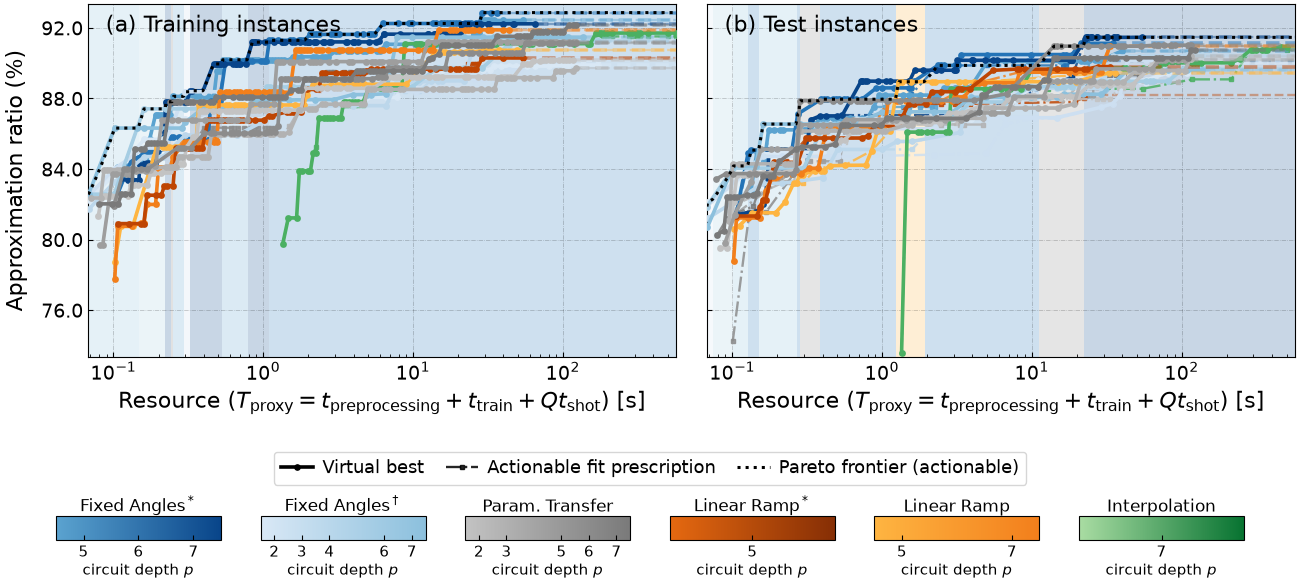

In [11]:
# ── Noiseless calibrated plot (2.47 kHz hardware rate, raw samples) ──────────
_all_nl = pd.concat(
    [df for df in [calib_nl_vb_test_df, calib_nl_vb_train_df,
                   calib_nl_fit_test_df, calib_nl_fit_train_df]
     if not df.empty and 'resource' in df.columns and 'method_label' in df.columns],
    ignore_index=True,
)
_all_nl['resource'] = pd.to_numeric(_all_nl['resource'], errors='coerce')
_all_nl = _all_nl[_all_nl['resource'] > 0].dropna(subset=['resource'])
_per_nl = _all_nl.groupby('method_label')['resource'].agg(['min', 'max'])
# Full union of all method ranges; curves hold their last value to the right edge.
_xl_left_nl = float(_per_nl['min'].min())
_xl_right_nl = float(_per_nl['max'].max())
MULTI_METHOD_XLIM_NOISELESS = (_xl_left_nl, _xl_right_nl) if _xl_left_nl < _xl_right_nl else None
print(f'Noiseless calibrated xlim: {MULTI_METHOD_XLIM_NOISELESS}')

plot_multi_method_window_sticker_component_panels(
    training_virtual_best_df=calib_nl_vb_train_df,
    training_fitted_prescription_df=calib_nl_fit_train_df,
    test_virtual_best_df=calib_nl_vb_test_df,
    test_fitted_prescription_df=calib_nl_fit_test_df,
    filename='multi_method_window_sticker_hw_noiseless',
    plot_dir=PLOT_DIR,
    approx_ylim=shared_approx_ylim,
    approx_yticks=shared_approx_yticks,
    show_ci=SHOW_WINDOW_STICKER_CI,
    xlim=MULTI_METHOD_XLIM_NOISELESS,
    extend_curves_to_xlim=True,
)


## Comparing Against Real Hardware: Best-Bitstring Pareto Overlay

The two notebooks measure approximation ratio differently: `Analysis.ipynb`'s hardware Pareto/recommendation plot reports the *expectation value* of the energy over the full measured shot distribution (`QAOAHardware.expected_energy`), while this notebook's simulated results report the *best single observed bitstring* (`best_prefix_metrics` -> `BestApproximationRatio`). These are not the same quantity, so overlaying them as-is would not be a fair comparison.

To compare apples to apples, this section re-derives `Analysis.ipynb`'s real hardware dataset here, but replaces its expectation-value approximation ratio with a best-observed-bitstring ratio computed from the *same* raw `counts` histograms every hardware job already recorded (every unique bitstring actually measured, picking the single best one per job -- exactly how this notebook's own metric is defined). The resource axis (QPU execution time + training cost) and Pareto-frontier construction are otherwise identical to `Analysis.ipynb`. Restricted to the depths this notebook's own comparison actually uses (`COMPARISON_RESULT_TAGS`), not `Analysis.ipynb`'s full p=2-10 default, so both curves cover the same strategies.

In [ ]:
# ── Re-derive Analysis.ipynb's real hardware dataset with a best-bitstring
# approximation ratio (instead of its default expectation-value metric), so
# it's comparable to this notebook's own BestApproximationRatio metric.
_bb_graph_type = GRAPH_TYPE
_bb_num_nodes = NUM_NODES
_bb_data_dir = str(QAOA_PARAMETER_SETTING_ROOT / "data")
_bb_inst_path = str(QAOA_PARAMETER_SETTING_ROOT / "instances")
_bb_minmax_path = str(QAOA_PARAMETER_SETTING_ROOT / "data" / "minmax_cuts")
# Same depths actually used across this notebook's comparison
# (COMPARISON_RESULT_TAGS), not Analysis.ipynb's full p=2-10 default, so both
# curves compare the same strategies at the same depths.
_bb_p_list = sorted({
    int(_m.group(1))
    for _tag in COMPARISON_RESULT_TAGS
    for _m in [re.search(r"_p(\d+)", _tag)]
    if _m
})
_bb_instance_list = list(range(10))
# Training-file lookup needs a WIDER depth net than the hardware-execution
# depths above: QAOATraining.locate_training_instance matches files by the
# depth suffix baked into the TRAINING filename, which for recursively
# trained strategies (e.g. Interp/RecursionTrainer) is the training run's
# target depth (often 10), not the depth it was later executed at on
# hardware. Analysis.ipynb searches p=2..10 for both hardware and training
# lookups for exactly this reason -- match that range here for the training
# search so strategies like Interp aren't silently dropped for NaN training
# cost (and thus missing from the frontier) just because their training
# file's depth suffix falls outside COMPARISON_RESULT_TAGS's depths.
_bb_training_p_list = list(range(2, 11))

_bb_instance_file_paths = [
    _load_problem_instance(
        _bb_inst_path, _bb_graph_type, _bb_num_nodes, _inst,
        degree="None", ER_probability="None", swap_layers="None",
    )
    for _inst in _bb_instance_list
]
_bb_instance_path_map = {
    _p.stem.split("_")[0].zfill(3): _p
    for _sub in _bb_instance_file_paths
    for _p in _sub
}
_bb_instance_context_cache: dict[str, dict] = {}

_bb_hw_paths = []
for _p in _bb_p_list:
    _hw_data_path = _set_data_path(_bb_data_dir, True, False, _bb_graph_type)
    for _inst in _bb_instance_list:
        _bb_hw_paths.extend(
            _QAOAHardware.locate_hardware_instance(
                _hw_data_path, _bb_graph_type, str(_inst), str(_bb_num_nodes), str(_p),
                ER_probability="None", swap_layers="None", degree="None",
            )
        )

_bb_all_hw = []
for _ip in _bb_hw_paths:
    _n = Path(_ip).name[:3]
    if _n not in _bb_instance_context_cache:
        _bb_instance_context_cache[_n] = _load_maxcut_instance_context(_bb_instance_path_map[_n])
    _ctx = _bb_instance_context_cache[_n]
    _bb_all_hw.extend(
        _QAOAHardware.load_hardware_instance(
            _ip, objective_from_bitstring=_maxcut_energy_from_bitstring,
            objective_context=_ctx, energy_mode="full", top_pc=None,
        )
    )

df_hardware_bb = pd.DataFrame([
    {
        "instance_name": _o.instance_name, "QPU_time (s)": _o.QPU_time, "num_shots": _o.num_shots,
        "problem_class": _o.problem_class, "training_method": _o.training_method,
        "expected_energy": _o.expected_energy, "file_name": _o.file_name, "job_p": _o.job_p,
        "training_p": _o.training_p, "counts": _o.counts, "params": _o.params, "trainer": _o.trainer,
    }
    for _o in _bb_all_hw
])
df_hardware_bb = df_hardware_bb[
    df_hardware_bb["problem_class"].str.lower().eq("maxcut")
    & df_hardware_bb["file_name"].str.contains("_MC_", na=False)
].copy()

# Best-observed-bitstring approximation ratio: every unique bitstring this
# hardware job actually measured (via its raw counts histogram), take the
# single best one -- the same definition best_prefix_metrics uses for this
# notebook's own BestApproximationRatio, just applied to a counts dict
# instead of an ordered shot stream (order doesn't matter for a global best).
_bb_minmax_cache: dict[str, tuple[float, float, float]] = {}

df_hardware_bb[["approximation_ratio", "best_bitstring"]] = df_hardware_bb.apply(
    _best_bitstring_ar,
    axis=1,
    minmax_path=_bb_minmax_path,
    graph_type=_bb_graph_type,
    num_nodes=_bb_num_nodes,
    minmax_cache=_bb_minmax_cache,
    instance_context_cache=_bb_instance_context_cache,
)

# Training-side data + cost resolution, unchanged from Analysis.ipynb.
_bb_training_paths = []
for _p in _bb_training_p_list:
    _train_data_path = _set_data_path(_bb_data_dir, False, True, _bb_graph_type)
    for _inst in _bb_instance_list:
        _bb_training_paths.extend(
            _QAOATraining.locate_training_instance(
                _train_data_path, _bb_graph_type, _inst, _bb_num_nodes, _p,
                ER_probability="None", swap_layers="None", degree="None",
            )
        )

_bb_all_training = [_QAOATraining.load_training_instance(_ip) for _ip in _bb_training_paths]
df_training_bb = pd.DataFrame([
    {
        "file_name": _o.file_name, "physical_training_file": _o.physical_file_name,
        "pre_processing_time": _o.pre_processing_time, "pre_processor_name": _o.pre_processor_name,
        "train_duration_per_iter": _o.train_duration_per_iter, "expected_energy_per_iter": _o.expected_energy_per_iter,
        "trainer_name_per_iter": _o.trainer_name_per_iter, "train_duration_per_layer": _o.train_duration_per_layer,
        "expected_energy_per_layer": _o.expected_energy_per_layer, "trainer_name_per_layer": _o.trainer_name_per_layer,
        "num_depth_iter": _o.num_depth_iter, "stage_summaries": _o.stage_summaries,
    }
    for _o in _bb_all_training
])
df_training_bb = df_training_bb.map(
    lambda x: np.nan if (x is None or x == [] or x == {} or _is_empty_nested_list(x)) else x
)

_bb_flat_rows = []
for _, _row in df_training_bb.iterrows():
    _file, _phys = _row["file_name"], _row["physical_training_file"]
    _outer_dur, _outer_eng, _outer_trn = _row["train_duration_per_iter"], _row["expected_energy_per_iter"], _row["trainer_name_per_iter"]
    _inner_dur, _inner_eng, _inner_trn, _inner_depth = _row["train_duration_per_layer"], _row["expected_energy_per_layer"], _row["trainer_name_per_layer"], _row["num_depth_iter"]
    if not isinstance(_outer_dur, list):
        continue
    for _i in range(len(_outer_dur)):
        _trn = _outer_trn[_i] if isinstance(_outer_trn, list) and _i < len(_outer_trn) and isinstance(_outer_trn[_i], dict) else {}
        _min_args = _trn.get("minimize_args") if isinstance(_trn.get("minimize_args"), dict) else {}
        _opts = _min_args.get("options") if isinstance(_min_args.get("options"), dict) else {}
        _bb_flat_rows.append({
            "file_name": _file, "physical_training_file": _phys, "level": "outer", "stage": _i, "iteration": _i,
            "duration": _outer_dur[_i] if _i < len(_outer_dur) else np.nan,
            "energy": _outer_eng[_i] if isinstance(_outer_eng, list) and _i < len(_outer_eng) else np.nan,
            "trainer": _trn.get("trainer_name"), "trainer_name": _trn.get("trainer_name"),
            "method": _min_args.get("method"), "maxiter": _opts.get("maxiter"), "depth_step": np.nan,
        })
        _dur_i = _inner_dur[_i] if isinstance(_inner_dur, list) and _i < len(_inner_dur) and isinstance(_inner_dur[_i], list) else []
        _eng_i = _inner_eng[_i] if isinstance(_inner_eng, list) and _i < len(_inner_eng) and isinstance(_inner_eng[_i], list) else []
        _trn_i = _inner_trn[_i] if isinstance(_inner_trn, list) and _i < len(_inner_trn) and isinstance(_inner_trn[_i], list) else []
        _depth_i = _inner_depth[_i] if isinstance(_inner_depth, list) and _i < len(_inner_depth) and isinstance(_inner_depth[_i], list) else []
        for _dur, _eng, _trn2, _depth in zip(_dur_i, _eng_i, _trn_i, _depth_i):
            _trn2 = _trn2 if isinstance(_trn2, dict) else {}
            _min_args2 = _trn2.get("minimize_args") if isinstance(_trn2.get("minimize_args"), dict) else {}
            _opts2 = _min_args2.get("options") if isinstance(_min_args2.get("options"), dict) else {}
            _bb_flat_rows.append({
                "file_name": _file, "physical_training_file": _phys, "level": "inner", "stage": _i, "iteration": _i, "depth_step": _depth,
                "duration": _dur, "energy": _eng, "trainer": _trn2.get("trainer_name"), "trainer_name": _trn2.get("trainer_name"),
                "method": _min_args2.get("method"), "maxiter": _opts2.get("maxiter"),
            })
df_flat_bb = pd.DataFrame(_bb_flat_rows)

df_hardware_new_bb = _resolve_hardware_training_costs(df_training_bb, df_flat_bb, df_hardware_bb)

# Recalibrate QPU_time using the SAME paper-measured shot rate
# (arXiv:2606.05311v1, via _t_calib_noiseless defined above) already used for
# the simulated Noiseless curve, so
# the hardware Pareto sits on the same resource basis instead of the raw,
# even-split-per-job JSON-derived QPU_time. Only QPU_time is shot-rate
# dependent -- total_train_cost is real classical wall-clock time (COBYLA
# etc. running on a classical machine), unrelated to the QPU's shot rate, so
# it is left unscaled.
_bb_job_p_int = df_hardware_new_bb["job_p"].astype(int)
df_hardware_new_bb["QPU_time_noiseless (s)"] = df_hardware_new_bb["num_shots"] * _bb_job_p_int.map(_t_calib_noiseless)

df_frontier_bb_nl = _build_hw_frontier(
    "QPU_time_noiseless (s)", df_hardware_new_bb, df_hardware_bb, _bb_num_nodes
)

# ── Overlay: this notebook's simulated Pareto frontier (test instances) vs.
# the best-bitstring real-hardware frontier, BOTH recalibrated onto the same
# paper-measured shot rate, using a strategy-family colour map so colour says
# which strategy family + depth owns that segment of the frontier.
_nl_entries = _sim_entries(calib_nl_fit_test_df)

# Real hardware frontiers, labelled with the same "<family><opt-marker>
# (p=<depth>)" format the simulated curves use, so both datasets share one
# family colour map instead of an arbitrary flat colour.
_hw_frontier_nl = _label_hw_frontier(df_frontier_bb_nl)

_all_labels = sorted(
    {lbl for lbl, _, _, _, _ in _nl_entries}
    | set(_hw_frontier_nl['method_label'])
)
color_map, family_labels, family_styles = build_qps_method_color_map(_all_labels)


winning_labels = (
    _sim_winners(_nl_entries, color_map) | set(_hw_frontier_nl['method_label'])
)
dynamic_family_labels = {
    fam: [lbl for lbl in labels if lbl in winning_labels]
    for fam, labels in family_labels.items()
    if any(lbl in winning_labels for lbl in labels)
}
# One legend row below the axes, in place of the old depth colorbar strip.
fig, ax = plt.subplots(figsize=(9, 7.0))
_plot_x_all: list[float] = []
_plot_y_all: list[float] = []
_depth_points: list[dict] = []

for entries, linestyle, marker in [(_nl_entries, '-', 'o')]:
    if not entries:
        continue
    colored_entries = [(lbl, color_map[lbl], xs, ys) for lbl, xs, ys, _, _ in entries]
    bounds_entries = [(xs, ci_lo, ci_hi) for _, xs, _, ci_lo, ci_hi in entries]
    x_lo = min(e[2][0] for e in colored_entries)
    x_hi = max(e[2][-1] for e in colored_entries)
    grid = np.logspace(np.log10(x_lo), np.log10(x_hi), 800)
    envelope, best_idx = _pareto_envelope_and_owner(colored_entries, grid)
    ci_lower, ci_upper = _pareto_envelope_bounds(bounds_entries, grid, best_idx)
    method_colors = [c[1] for c in colored_entries]
    # Shared helper rather than an inline loop, so this figure gets the same
    # joined-at-the-takeover envelope and the same per-family marker styling
    # (hollow for a dagger method, dark-edged for a starred one) as the
    # cost-model comparison figure.
    _method_styles = [family_styles[_detect_method_family(c[0])] for c in colored_entries]
    _marker_idx = _draw_pareto_envelope_segments(
        ax, grid, envelope, best_idx, method_colors,
        method_styles=_method_styles, linestyle=linestyle, marker=marker,
    )
    _finite = np.isfinite(envelope)
    _plot_x_all.extend(grid[_finite].tolist())
    _plot_y_all.extend(envelope[_finite].tolist())
    _depth_points.extend(
        {'x': float(grid[_i]), 'y': float(envelope[_i]),
         'p': _label_depth(colored_entries[int(best_idx[_i])][0]),
         'marker': marker,
         'color': family_label_color(_detect_method_family(colored_entries[int(best_idx[_i])][0]),
                                     method_colors[int(best_idx[_i])]),
         'style': _method_styles[int(best_idx[_i])]}
        for _i in _marker_idx if np.isfinite(envelope[_i])
    )

    # Error-bar whiskers at exactly the marker positions, coloured by
    # whichever family owns the envelope at that point.
    for _idx in _marker_idx:
        if not np.isfinite(envelope[_idx]) or best_idx[_idx] < 0:
            continue
        _lo, _hi, _env = ci_lower[_idx], ci_upper[_idx], envelope[_idx]
        if not (np.isfinite(_lo) and np.isfinite(_hi)):
            continue
        ax.errorbar(
            grid[_idx], _env,
            yerr=[[max(0.0, _env - _lo)], [max(0.0, _hi - _env)]],
            fmt='none', ecolor=method_colors[int(best_idx[_idx])],
            capsize=3, elinewidth=1.1, zorder=5.5,
        )
        _plot_y_all.extend([float(_lo), float(_hi)])

# Real hardware, one curve per calibration -- drawn as a step curve using the
# SAME per-family colour map as the simulated curves, with a dotted linestyle
# extending the existing solid=Noiseless convention:
# densely-spaced dots for the Noiseless-calibrated hardware curve, sparser
_hw_x_extend_candidates = list(_plot_x_all)
_hw_x_nl_check = pd.to_numeric(_hw_frontier_nl['dur_mean'], errors='coerce').to_numpy(dtype=float)
if _hw_x_nl_check.size:
    _hw_x_extend_candidates.append(_hw_x_nl_check[-1])
_hw_x_extend_to = max(_hw_x_extend_candidates) if _hw_x_extend_candidates else 1.0

_hw_halo = [_pe.Stroke(linewidth=4.0, foreground='white'), _pe.Normal()]

# Real hardware (noiseless calibration): thin dotted step line, same
# per-family colour map as the simulated curves, with a square marker at
# each actual measured point (not at the synthetic right-edge extension).
_hw_x_nl = pd.to_numeric(_hw_frontier_nl['dur_mean'], errors='coerce').to_numpy(dtype=float)
_hw_y_nl = pd.to_numeric(_hw_frontier_nl['ar_mean'], errors='coerce').to_numpy(dtype=float) * 100.0
if _hw_x_nl.size:
    _hw_colors_nl = [color_map[lbl] for lbl in _hw_frontier_nl['method_label']]
    for _i in range(len(_hw_x_nl)):
        _x_start = _hw_x_nl[_i]
        _x_end = _hw_x_nl[_i + 1] if _i + 1 < len(_hw_x_nl) else _hw_x_extend_to
        ax.plot(
            [_x_start, _x_end], [_hw_y_nl[_i], _hw_y_nl[_i]],
            color=_hw_colors_nl[_i], linestyle=':', linewidth=2.2,
            path_effects=_hw_halo, zorder=6,
        )
        _plot_x_all.extend([_x_start, _x_end])
        _plot_y_all.append(_hw_y_nl[_i])
        if _i > 0:
            ax.plot(
                [_x_start, _x_start], [_hw_y_nl[_i - 1], _hw_y_nl[_i]],
                color=_hw_colors_nl[_i], linestyle=':', linewidth=2.2,
                path_effects=_hw_halo, zorder=6,
            )
    # _hw_y_nl is already in percent, so these need no further scaling.
    _depth_points.extend(
        {'x': float(_x), 'y': float(_y), 'p': _label_depth(_lbl),
         'marker': 's', 'color': family_label_color(_detect_method_family(_lbl), _c),
         'style': {'markerfacecolor': _c, 'markeredgecolor': 'white', 'markeredgewidth': 0.8}}
        for _x, _y, _lbl, _c in zip(_hw_x_nl, _hw_y_nl, _hw_frontier_nl['method_label'], _hw_colors_nl)
        if np.isfinite(_x) and np.isfinite(_y)
    )
    ax.scatter(
        _hw_x_nl, _hw_y_nl, c=_hw_colors_nl, marker='s', s=100,
        edgecolor='white', linewidth=0.8, zorder=7,
    )
    # Error-bar whiskers at each actual measured point, from the same
    # dur_sem/ar_sem (standard error over the ten test instances) that
    # build_recommendation_data already computes.
    _hw_x_sem = pd.to_numeric(_hw_frontier_nl.get('dur_sem'), errors='coerce').to_numpy(dtype=float)
    _hw_y_sem = pd.to_numeric(_hw_frontier_nl.get('ar_sem'), errors='coerce').to_numpy(dtype=float) * 100.0
    _hw_has_err = np.isfinite(_hw_x_sem) & np.isfinite(_hw_y_sem)
    if _hw_has_err.any():
        for _i in np.flatnonzero(_hw_has_err):
            ax.errorbar(
                _hw_x_nl[_i], _hw_y_nl[_i],
                xerr=_hw_x_sem[_i], yerr=_hw_y_sem[_i],
                fmt='none', ecolor=_hw_colors_nl[_i], capsize=3, elinewidth=1.1, zorder=6.5,
            )
            _plot_y_all.extend([float(_hw_y_nl[_i] - _hw_y_sem[_i]), float(_hw_y_nl[_i] + _hw_y_sem[_i])])

ax.set_xscale('log')
# Padding in decades / span fraction, matching the cost-model comparison
# figure: without it the cheapest points sit on the spine and their depth
# labels have nowhere to go.
_X_PAD_DECADES = 0.16
_Y_MARGIN = 0.08
if _plot_x_all:
    _lo_dec, _hi_dec = np.log10(min(_plot_x_all)), np.log10(max(_plot_x_all))
    ax.set_xlim(10 ** (_lo_dec - _X_PAD_DECADES), 10 ** (_hi_dec + 0.5 * _X_PAD_DECADES))
if _plot_y_all:
    _y_pad = max(0.4, _Y_MARGIN * (max(_plot_y_all) - min(_plot_y_all)))
    ax.set_ylim(min(_plot_y_all) - _y_pad, 96)  # headroom above the topmost curve
ax.set_xlabel('Resource (s)')
ax.set_ylabel('Approximation ratio (%)')
ax.grid(True, which='major', color='0.45', alpha=0.55, linewidth=0.7)
ax.grid(True, which='minor', color='0.65', alpha=0.35, linewidth=0.5)

# Linestyle legend distinguishes data source (simulated vs. real hardware);
# family colour is read off the colorbars below.
_source_handles = [
    Line2D([0], [0], color='black', linestyle='-', linewidth=2.6, marker='o', markersize=10, label='Noiseless (MPS (Aer))'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=2.2, marker='s', markersize=10, label='Classical training + ibm_boston'),
]

# Calibration/source legend sits inside the axes (bottom-right, where the
# curves leave empty space); only the strategy legend needs a reserved row.
bottom_reserved = 0.10
fig.tight_layout(rect=[0.0, bottom_reserved, 1.0, 1.0])

ax.legend(
    handles=_source_handles,
    loc='lower right',
    frameon=True,
    ncol=1,
    handlelength=2.4,
    handletextpad=0.5,
    labelspacing=0.4,
)

_family_handles = family_legend_handles(dynamic_family_labels, family_styles)
if _family_handles:
    fig.legend(handles=_family_handles, loc='lower center',
               ncol=min(len(_family_handles), 4), frameon=False, fontsize=11,
               handlelength=2.2, handletextpad=0.6, columnspacing=1.8,
               bbox_to_anchor=(0.5, 0.005))

# Densest cluster of takeovers goes into an inset, as the recommendation plot
# does; the main axes label everything else and steer clear of the inset.
_inset_members, _inset_ax = add_cluster_inset(ax, _depth_points)
_reserved = []
if _inset_ax is not None:
    fig.canvas.draw()
    _reserved.append(_inset_ax.get_window_extent(fig.canvas.get_renderer()).expanded(1.06, 1.06))
annotate_frontier_depths(
    ax, [pt for _i, pt in enumerate(_depth_points) if _i not in set(_inset_members)],
    reserved=_reserved,
)

save_current_plot('pareto_frontier_vs_real_hardware_best_bitstring', PLOT_DIR)
plt.show()

## Resource-cost model: charging for circuit preparation

Figure 12 prices a run by the shots it consumes,
$T_{\mathrm{proxy}} = t_{\mathrm{preprocessing}} + NMt_{\mathrm{shot}} + Qt_{\mathrm{shot}}$,
which treats those shots as the whole cost of getting results off the device.

A hardware measurement disagrees. Submitting one 144-node heavy-hex MaxCut
circuit and asking for $M$ shots takes about 13.87 s to return, and that time
barely moves as $M$ goes from 10 to 10,000, because compilation, transfer,
queueing and control-electronics load dominate rather than the shots. Every
submitted circuit therefore owes $t_{\mathrm{prep}}$:

$$T_{\mathrm{proxy}} = t_{\mathrm{preprocessing}}
  + n_{\mathrm{evals}}\,(t_{\mathrm{prep}} + Mt_{\mathrm{shot}})
  + (t_{\mathrm{prep}} + Qt_{\mathrm{shot}}),$$

where $n_{\mathrm{evals}}$ counts the circuits the optimizer actually
submitted, which runs above the requested COBYLA `maxiter` ($N = 10$ submits
15 circuits, $N = 100$ submits 114).

Because the prescription is an argmax under a cost model, changing the cost
model changes which $(N, M, Q)$ is advised at each budget. Both panels are
therefore rebuilt from the exact points under their own cost model, by
`run_latency_recost.py`, which re-prices the already-simulated points and
redoes only the cheap post-processing. **No simulation is re-run**: the
$(N, M, Q) \rightarrow$ approximation-ratio mapping is physics and carries no
dependence on how resources are priced.

The two models differ in two ways, both corrections of the published one.
The charge itself is the large one. The other is that the charged model bills
the training shots each run actually recorded, $n_{\mathrm{evals}}\,M$, where
the published model bills the $NM$ it asked for; at $405\,\mu$s a shot that
is at most a few seconds against charges of hundreds.

Every family is capped at $Q \le 10{,}000$ so that all four sit on one
sampling grid. The campaigns did not explore the same budgets. Parameter
Transfer and the zero-training Fixed Angles runs reach $Q$ of a few hundred
thousand, while every family that optimizes its angles stops at $Q = 10{,}000$.
That gap is harmless while shots dominate the cost, but a fixed per-submission
charge compresses the cheap end until it decides the whole picture, and
uncapped the charged frontier goes almost entirely to Parameter Transfer on
sampling access rather than on merit.

Two caveats belong in the caption. The charge makes shots nearly free below
$M \approx 25{,}000$ while the explored grid stops at $M = 1000$, so the
charged panel's advice sits at the grid ceiling and understates what a
re-optimised grid would reach. And the bootstrap is unseeded, so re-running
shifts which points are retained.

The measured hardware curve is priced by the same two models. Its resource is
classical training wall-clock plus $Q\,t_{\mathrm{shot}}$ on the noiseless
basis (the measured QPU time is replaced by that recalibration, so it carries
no submission overhead of its own). Each run trained classically and then
submitted one sampling job, so the charged panel adds a single
$t_{\mathrm{prep}}$ to it; the shot-only panel adds nothing.

Shot time only (published model) / Noiseless (MPS): 16 roots, 357 rows, resource [0.06638, 64.78] s
+ 13.87 s per submitted circuit / Noiseless (MPS): 16 roots, 265 rows, resource [13.93, 4073] s
Saved: plots/pareto_frontier_cost_model_comparison_Q10000.pdf and .png


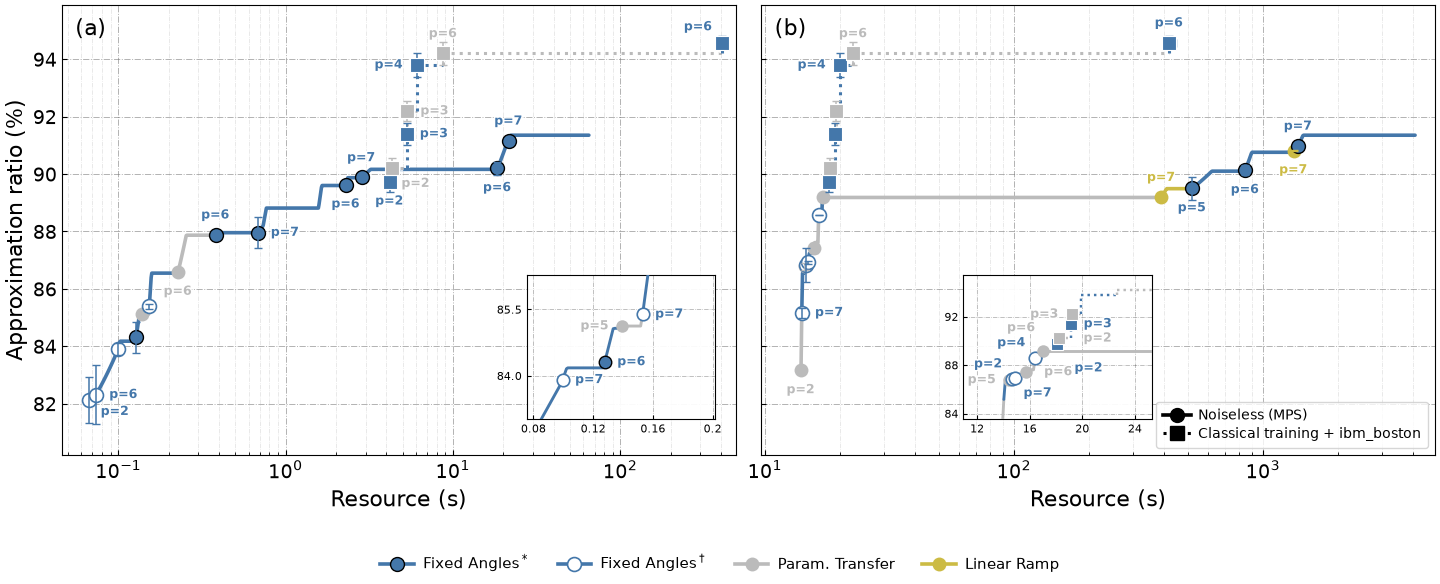

In [13]:
# ── Resource-cost model comparison. Generate the inputs first; no simulation
# is re-run, and the slim point caches make repeat passes quick:
#     python examples/IBM_QAOA/run_latency_recost.py --no-hardware-shot-times --q-cap 10000
# The shot basis is fixed when the roots are generated rather than rescaled
# afterwards: the preparation charge is real wall-clock time and must never be
# scaled by a shot-rate factor, unlike the shot terms.
CIRCUIT_PREP_TIME = 13.87
_prep = 'prep' + f'{CIRCUIT_PREP_TIME:g}'.replace('.', 'p') + 's'

# Every family capped at Q <= 10,000, the largest sampling budget the
# optimized families were ever given, so all four share one grid. Without the
# cap the charge hands the charged frontier to Param. Transfer on sampling
# access rather than on merit.
Q_CAP_SUFFIX = '_Q10000'

# Interp never reaches the frontier under either cost model and only stretches
# the resource axis. Remove it here to put it back.
COST_PANEL_EXCLUDED_TAGS = ['heavy_hex_144_I_full_p7_expanded']

# The hardware frontier's resource is classical training wall-clock plus
# num_shots * t_shot on the noiseless basis (cell 612c9536 replaces the
# measured QPU time with that recalibration), so it carries NO submission
# overhead of its own. Each hardware run trained classically and then
# submitted exactly one sampling job, so under the charged model it owes one
# t_prep, added via extra_cost in the charged panel only.
_HW_OVERLAY = {
    'label': 'Classical training + ibm_boston',
    'frontier_df': _hw_frontier_nl,
    'linestyle': ':',
    'marker': 's',
}


def _cost_panel_specs(baseline_suffix, charged_suffix):
    """Two panels, each carrying the noiseless curve plus the hardware overlay."""
    return [
        {
            'title': 'Shot time only (published model)',
            'calibrations': [
                {'label': 'Noiseless (MPS)', 'suffix': baseline_suffix,
                 'linestyle': '-', 'marker': 'o'},
            ],
            'hardware': dict(_HW_OVERLAY),
        },
        {
            'title': f'+ {CIRCUIT_PREP_TIME:g} s per submitted circuit',
            'calibrations': [
                {'label': 'Noiseless (MPS)', 'suffix': charged_suffix,
                 'linestyle': '-', 'marker': 'o'},
            ],
            'hardware': dict(_HW_OVERLAY, extra_cost=CIRCUIT_PREP_TIME),
        },
    ]


_panels = load_cost_model_panels(
    _cost_panel_specs(f'prep0{Q_CAP_SUFFIX}', f'{_prep}{Q_CAP_SUFFIX}'),
    COMPARISON_RESULT_TAGS,
    PSS_RESULTS_BASE,
    exclude_tags=COST_PANEL_EXCLUDED_TAGS,
)

plot_cost_model_comparison_panels(
    panels=_panels,
    plot_dir=PLOT_DIR,
    filename=f'pareto_frontier_cost_model_comparison{Q_CAP_SUFFIX}',
    show_titles=False,
)